# Детекция объектов

## План ноутбука

1. Семантическая сегментация
1. Практика для семантической сегментации
1. Детекция объектов
1. Практика для детекции объектов

![](1.png)

## Задача семантической сегментации

![](2.png)

### Постановка задачи

 - Данные: изображение и его золотой стандарт сегментации
 - Пример датасетов: PASCAL VOC 2007 и 2012, CITYSCAPES, OXFORDIIITPET

![](3.jpeg)
![](4.png)

### Метрики качества

 - Попиксельная доля верных ответов:
$$\text{Accuracy}(y, a) = \dfrac{1}{n}\sum\limits_{i=1}^{n}[y_i = a_i]$$
 - Мера Жаккара:
$$J_k(y, a) = \dfrac{\sum\limits_{i=1}^{n}[y_i = k][a_i = k]}{\sum\limits_{i=1}^{n}\max([y_i = k], [a_i = k])}$$

IOU = TP / (TP+FP+FN)

### Функция потерь

Функция потерь абсолютно такая же как и для классификации, только мы классифицируем каждый пиксель и соответственно суммируем ошибку по всем пикселям.

## Архитектуры нейронных сетей для семантической сегментации

### Fully convolutional network

https://arxiv.org/abs/1411.4038

![](6.png)

 - Берем AlexNet
 - Только сверточные слои оставляем
 - Тензор с последнего слоя преобразуем с помощью сверток 1х1 в тензор такого же размера, только с нужным числом каналов (K по числу классов)
 - Повышаем разрешение

![](7.png)

#### Минусы?

 - Тензор на последнем слое маленький
 - Теряется информация о том, где объект, есть только информация, что он там был
 - Объекты похожи на пятна

### U-Net

https://arxiv.org/abs/1505.04597

![](8.png)

## Практика!

In [1]:
import torch
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
import torchvision.transforms as T
from torchvision.datasets import OxfordIIITPet

dataset = OxfordIIITPet('data', target_types='segmentation', download=False)

100%|██████████| 792M/792M [00:44<00:00, 17.8MB/s] 
100%|██████████| 19.2M/19.2M [00:01<00:00, 16.0MB/s]


In [4]:
dataset[0]

(<PIL.Image.Image image mode=RGB size=394x500>,
 <PIL.PngImagePlugin.PngImageFile image mode=L size=394x500>)

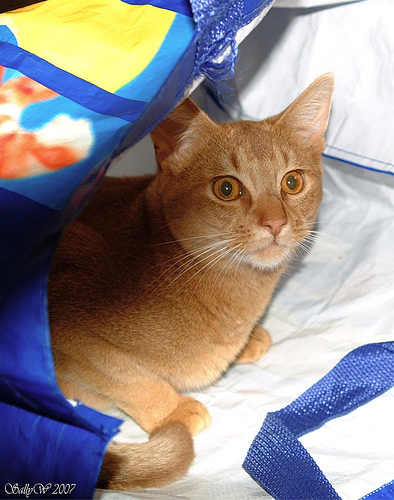

In [5]:
dataset[0][0]

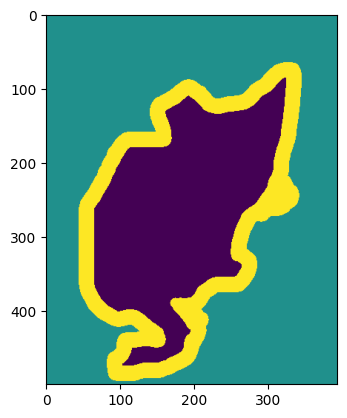

In [6]:
plt.imshow(dataset[0][1])

In [7]:
np.unique(dataset[0][1])

array([1, 2, 3], dtype=uint8)

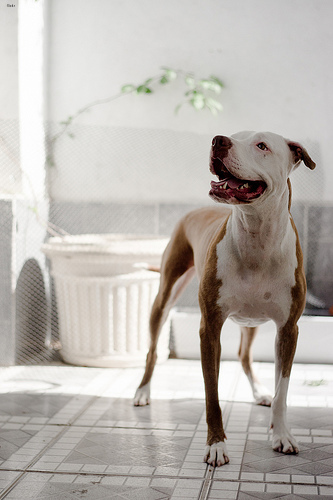

In [7]:
dataset[100][0]

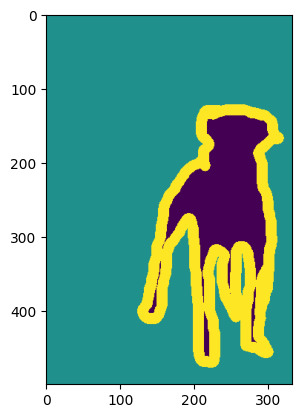

In [8]:
plt.imshow(dataset[100][1])

In [9]:
transform = T.Compose(
    [
        T.Resize((128, 128)),
        T.ToTensor(),
    ]
)

target_transform = T.Compose(
    [
        T.Resize((128, 128)),
        T.PILToTensor(),
        T.Lambda(lambda x: (x - 1).long())
    ]
)

train_dataset = OxfordIIITPet('data', transform=transform, target_transform=target_transform, target_types='segmentation')
valid_dataset = OxfordIIITPet('data', transform=transform, split='test', target_transform=target_transform, target_types='segmentation')

In [25]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=0, pin_memory=True)
valid_loader = DataLoader(valid_dataset, batch_size=64, shuffle=True, num_workers=0, pin_memory=True)

In [26]:
train_dataset[0][0].shape, train_dataset[0][1].shape

(torch.Size([3, 128, 128]), torch.Size([1, 128, 128]))

In [27]:
torch.unique(train_dataset[0][1])

tensor([0, 1, 2])

In [ ]:
from tqdm import tqdm
import torchmetrics

def train(model) -> float:
    model.train()

    train_loss = 0
    total = 0
    correct = 0
    
    iou_metric = torchmetrics.JaccardIndex(task='multiclass', num_classes=3, ignore_index=2).to(device)

    for x, y in tqdm(train_loader, desc='Train'):
        bs = y.size(0)

        x, y = x.to(device), y.squeeze(1).to(device)

        optimizer.zero_grad()

        output = model(x)

        loss = loss_fn(output, y)

        train_loss += loss.item()

        loss.backward()

        optimizer.step()

        _, y_pred = output.max(dim=1)
        mask = (y != 2)

        correct += ((y == y_pred) & mask).sum().item()
        total += mask.sum().item()
        # total += y.size(0) * y.size(1) * y.size(2)
        # correct += (y == y_pred).sum().item()
        iou_metric.update(output, y)

    train_loss /= len(train_loader)
    accuracy = correct / total

    return train_loss, accuracy, iou_metric.compute().item()

In [ ]:
@torch.inference_mode()
def evaluate(model, loader):
    model.eval()

    total_loss = 0
    total = 0
    correct = 0
    iou_metric = torchmetrics.JaccardIndex(task='multiclass', num_classes=3, ignore_index=2).to(device)

    for x, y in tqdm(loader, desc='Evaluation'):
        bs = y.size(0)

        x, y = x.to(device), y.squeeze(1).to(device)

        output = model(x)

        loss = loss_fn(output, y)

        total_loss += loss.item()

        _, y_pred = output.max(dim=1)
        correct += ((y == y_pred) & mask).sum().item()
        total += mask.sum().item()
        # total += y.size(0) * y.size(1) * y.size(2)
        # correct += (y == y_pred).sum().item()
        iou_metric.update(output, y)

    total_loss /= len(loader)
    accuracy = correct / total

    return total_loss, accuracy, iou_metric.compute().item()

In [30]:
from IPython.display import clear_output


def plot_stats(
    train_loss,
    valid_loss,
    train_accuracy,
    valid_accuracy,
    title
):
    plt.figure(figsize=(16, 8))

    plt.title(title + ' loss')

    plt.plot(train_loss, label='Train loss')
    plt.plot(valid_loss, label='Valid loss')
    plt.legend()
    plt.grid()

    plt.show()

    plt.figure(figsize=(16, 8))

    plt.title(title + ' accuracy')
    
    plt.plot(train_accuracy, label='Train accuracy')
    plt.plot(valid_accuracy, label='Valid accuracy')
    plt.legend()
    plt.grid()

    plt.show()

In [ ]:
import numpy as np
from PIL import Image

@torch.inference_mode()
def visualize(model, batch, max_items=10):
    model.eval()

    xs, ys = batch


    device = next(model.parameters()).device

    to_pil = T.ToPILImage()

    for i, (x, y) in enumerate(zip(xs, ys)):
        
        x_dev = x.to(device)

        # forward на модели
        logits = model(x_dev.unsqueeze(0))              # [1, C, H, W]
        prediction = logits.squeeze(0).argmax(dim=0)    # [H, W]

        x_cpu = x.detach().cpu()
        y_cpu = y.detach().cpu()
        pred_cpu = prediction.detach().cpu()

        fig, ax = plt.subplots(1, 3, figsize=(24, 8), facecolor='white')

        ax[0].imshow(to_pil(x_cpu))
        ax[1].imshow(to_pil(y_cpu.to(torch.uint8)))
        ax[2].imshow(to_pil(pred_cpu.to(torch.uint8)))

        for a, t in zip(ax, ['Original image', 'Segmentation mask', 'Prediction']):
            a.axis('off')
            a.set_title(t)

        plt.subplots_adjust(wspace=0, hspace=0.1)
        plt.show()

        if i >= max_items - 1:
            break

In [54]:
def whole_train_valid_cycle(model, num_epochs, title):
    train_loss_history, valid_loss_history = [], []
    train_iou_history, valid_iou_history = [], []

    for epoch in range(num_epochs):
        train_loss, train_accuracy, train_iou = train(model)
        valid_loss, valid_accuracy, valid_iou = evaluate(model, valid_loader)

        train_loss_history.append(train_loss)
        valid_loss_history.append(valid_loss)

        train_iou_history.append(train_iou)
        valid_iou_history.append(valid_iou)

        clear_output()

        plot_stats(
            train_loss_history, valid_loss_history,
            train_iou_history, valid_iou_history,
            title
        )

        visualize(model, next(iter(valid_loader)))

In [55]:
import torch.nn as nn


def conv_plus_conv(in_channels: int, out_channels: int):
    """
    Makes UNet block
    :param in_channels: input channels
    :param out_channels: output channels
    :return: UNet block
    """
    return nn.Sequential(
        nn.Conv2d(
            in_channels=in_channels,
            out_channels=out_channels,
            kernel_size=3,
            stride=1,
            padding=1
        ),
        nn.BatchNorm2d(num_features=out_channels),
        nn.LeakyReLU(0.2),
        nn.Conv2d(
            in_channels=out_channels,
            out_channels=out_channels,
            kernel_size=3,
            stride=1,
            padding=1
        ),
        nn.BatchNorm2d(num_features=out_channels),
        nn.LeakyReLU(0.2),
    )


class UNET(nn.Module):
    def __init__(self):
        super().__init__()

        base_channels = 16

        self.down1 = conv_plus_conv(3, base_channels)
        self.down2 = conv_plus_conv(base_channels, base_channels * 2)

        self.up1 = conv_plus_conv(base_channels * 2, base_channels)
        self.up2 = conv_plus_conv(base_channels * 4, base_channels)

        self.bottleneck = conv_plus_conv(base_channels * 2, base_channels * 2)

        self.out = nn.Conv2d(in_channels=base_channels, out_channels=3, kernel_size=1)

        self.downsample = nn.MaxPool2d(kernel_size=2, stride=2)

    def forward(self, x):
        # x.shape = (N, N, 3)

        residual1 = self.down1(x)  # x.shape: (N, N, 3) -> (N, N, base_channels)
        x = self.downsample(residual1)  # x.shape: (N, N, base_channels) -> (N // 2, N // 2, base_channels)

        residual2 = self.down2(x)  # x.shape: (N // 2, N // 2, base_channels) -> (N // 2, N // 2, base_channels * 2)
        x = self.downsample(residual2)  # x.shape: (N // 2, N // 2, base_channels * 2) -> (N // 4, N // 4, base_channels * 2)

        # LATENT SPACE DIMENSION DIM = N // 4
        # SOME MANIPULATION MAYBE
        x = self.bottleneck(x)  # x.shape: (N // 4, N // 4, base_channels * 2) -> (N // 4, N // 4, base_channels * 2)
        # SOME MANIPULATION MAYBE
        # LATENT SPACE DIMENSION DIM = N // 4

        x = nn.functional.interpolate(x, scale_factor=2)  # x.shape: (N // 4, N // 4, base_channels * 2) -> (N // 2, N // 2, base_channels * 2)
        x = torch.cat((x, residual2), dim=1)  # x.shape: (N // 2, N // 2, base_channels * 2) -> (N // 2, N // 2, base_channels * 4)
        x = self.up2(x)  # x.shape: (N // 2, N // 2, base_channels * 4) -> (N // 2, N // 2, base_channels)

        x = nn.functional.interpolate(x, scale_factor=2)  # x.shape: (N // 2, N // 2, base_channels) -> (N, N, base_channels)
        x = torch.cat((x, residual1), dim=1)  # x.shape: (N, N, base_channels) -> (N, N, base_channels * 2)
        x = self.up1(x)  # x.shape: (N, N, base_channels * 2) -> (N, N, base_channels)

        x = self.out(x).squeeze()  # x.shape: (N, N, base_channels) -> (N, N, 3)

        return x

In [56]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'mps' if torch.mps.is_available() else 'cpu')

print(device)
# print(torch.cuda.get_device_name())

loss_fn = nn.CrossEntropyLoss()

mps


In [57]:
from torch.optim import Adam
from tqdm.notebook import tqdm

model = UNET().to(device)
optimizer = Adam(model.parameters(), lr=1e-3)

In [58]:
plt.rcParams.update({'font.size': 16})

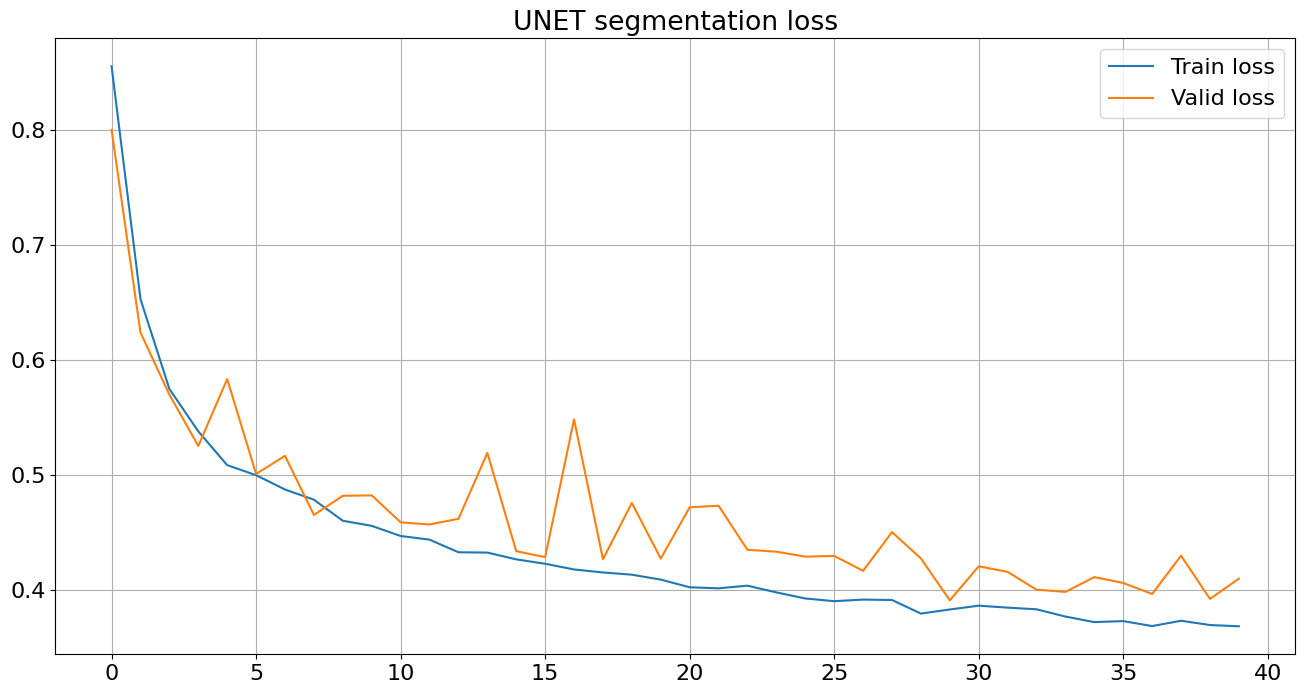

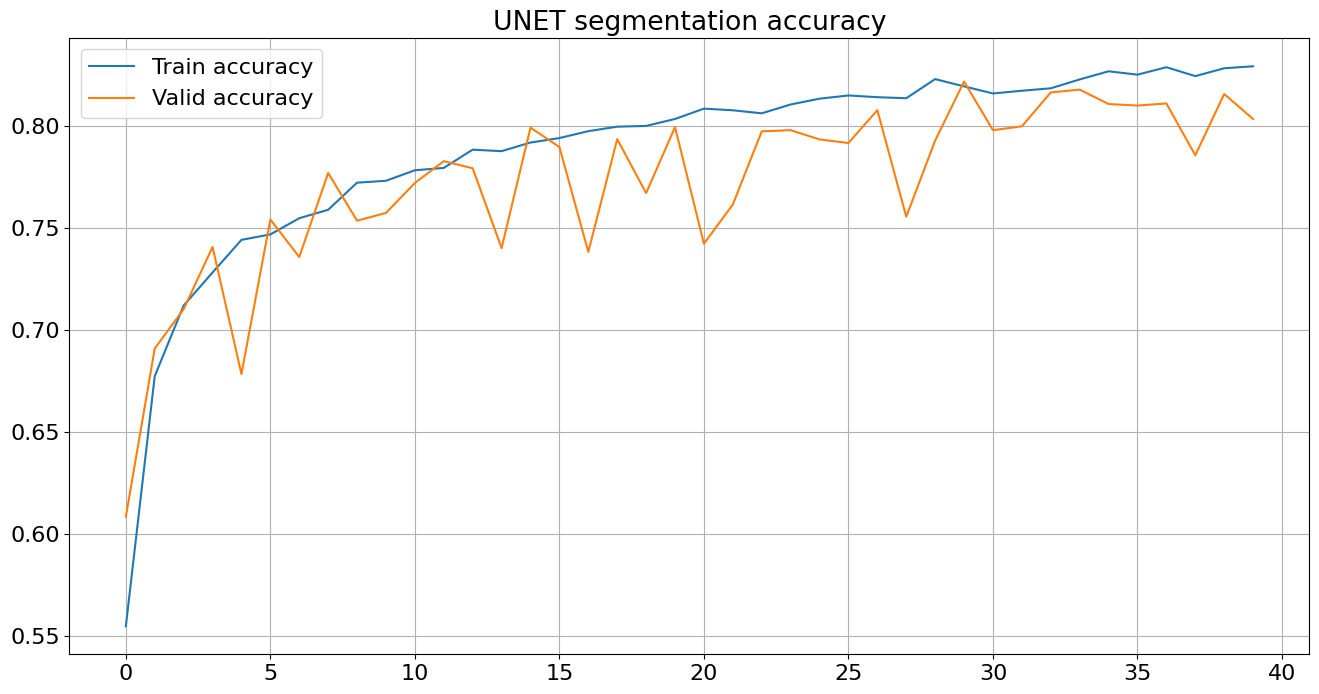

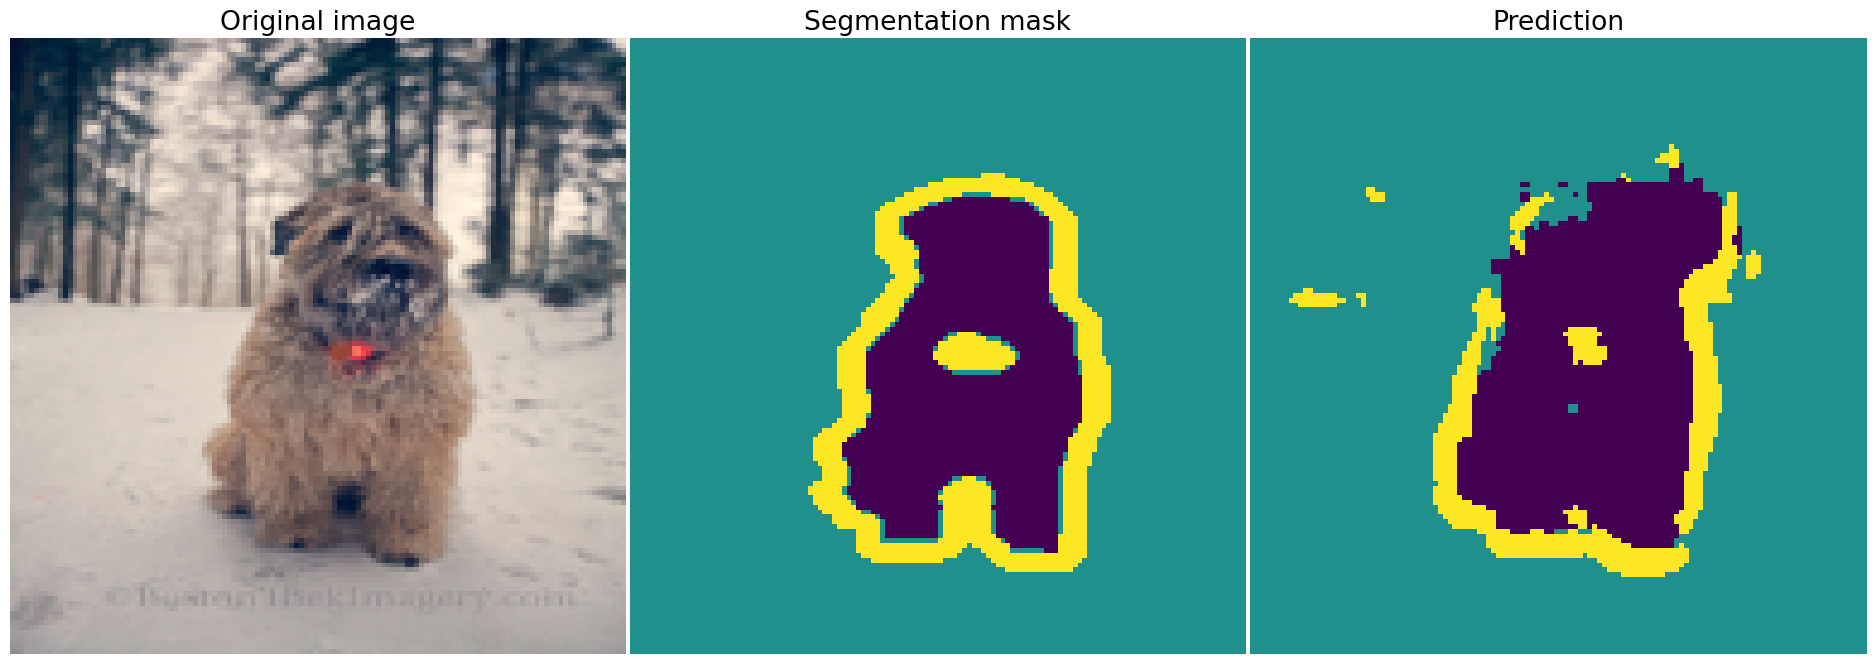

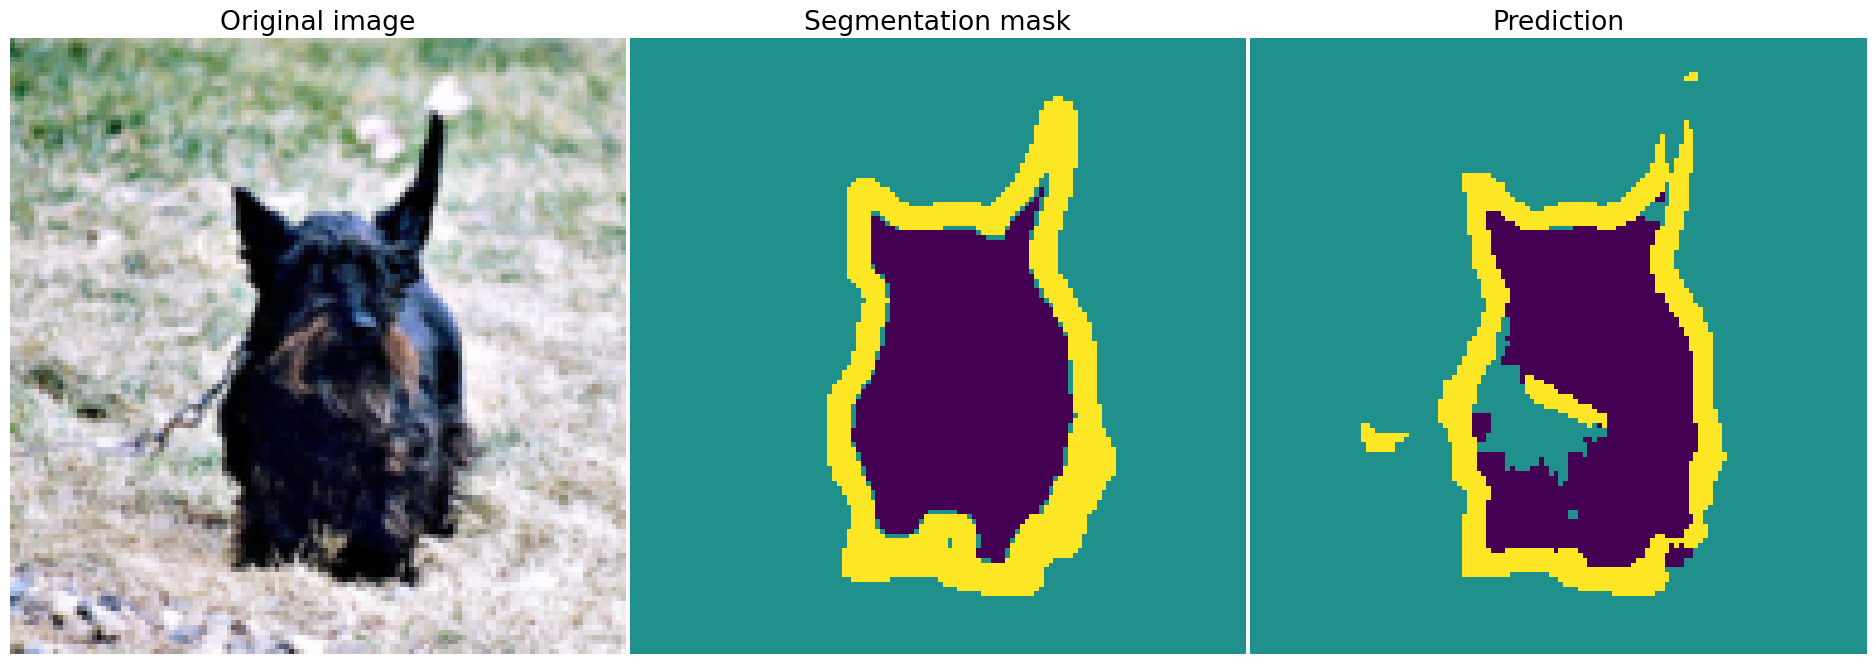

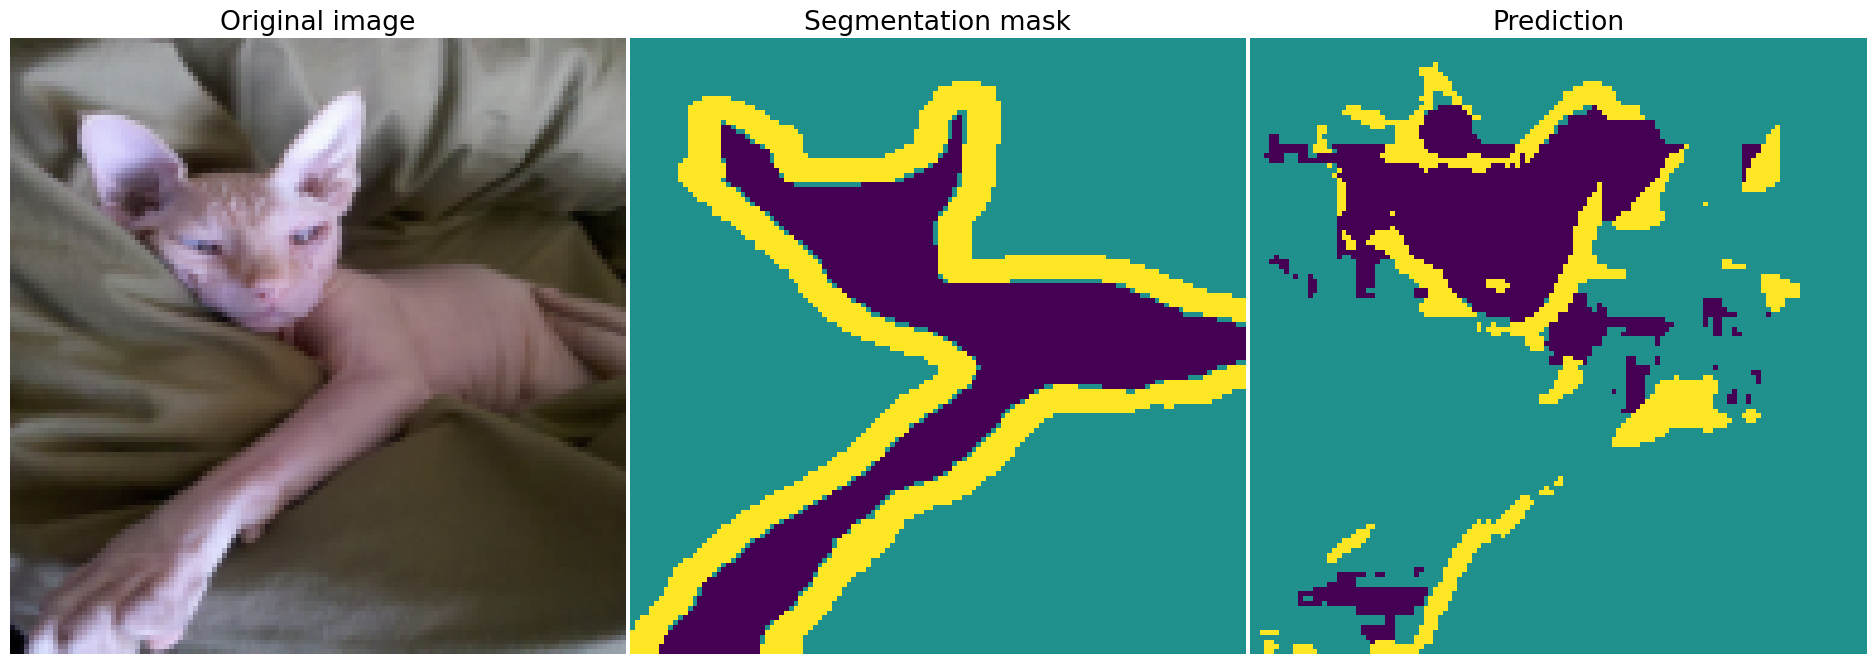

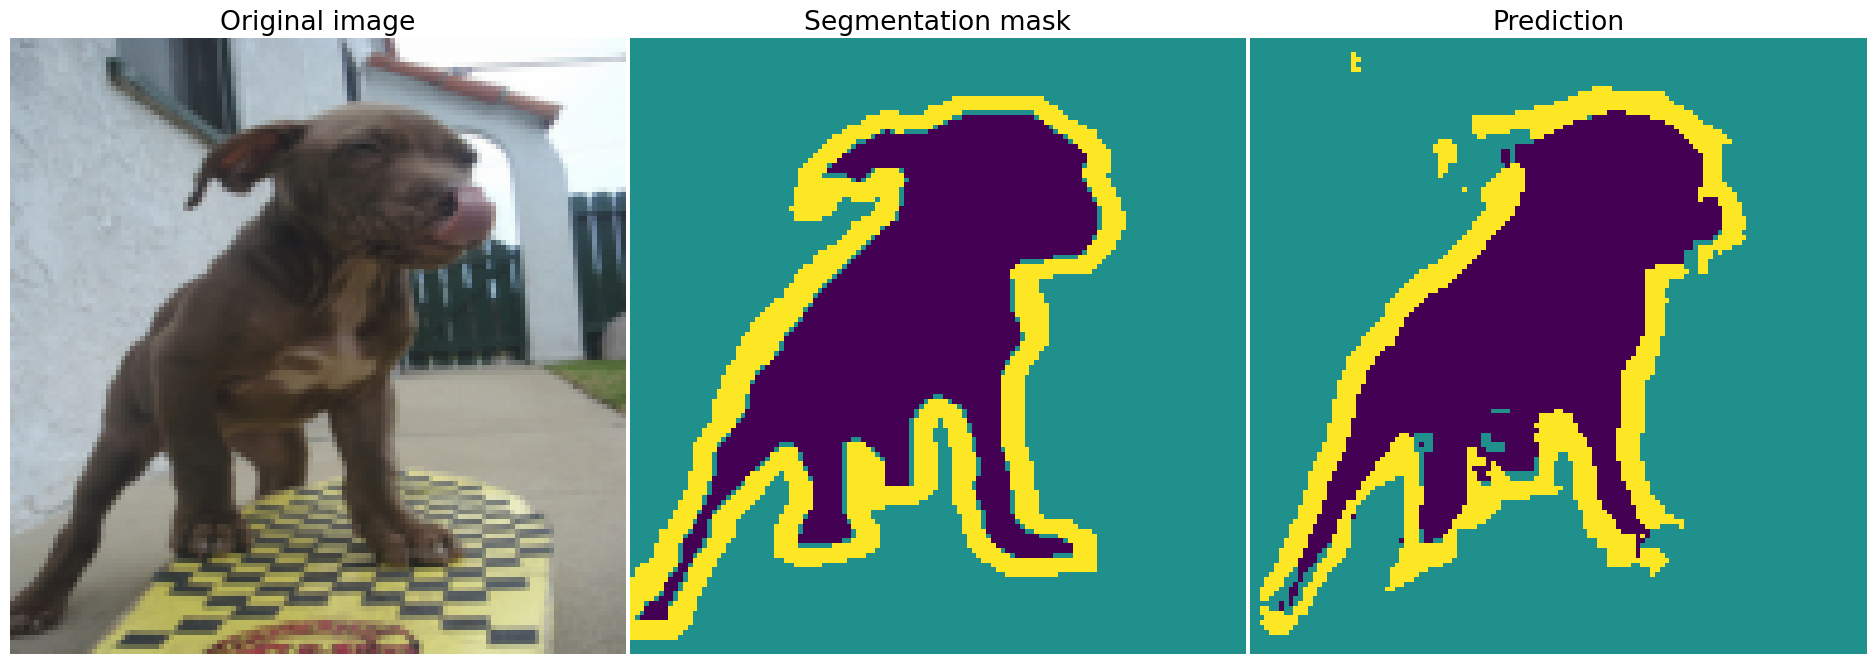

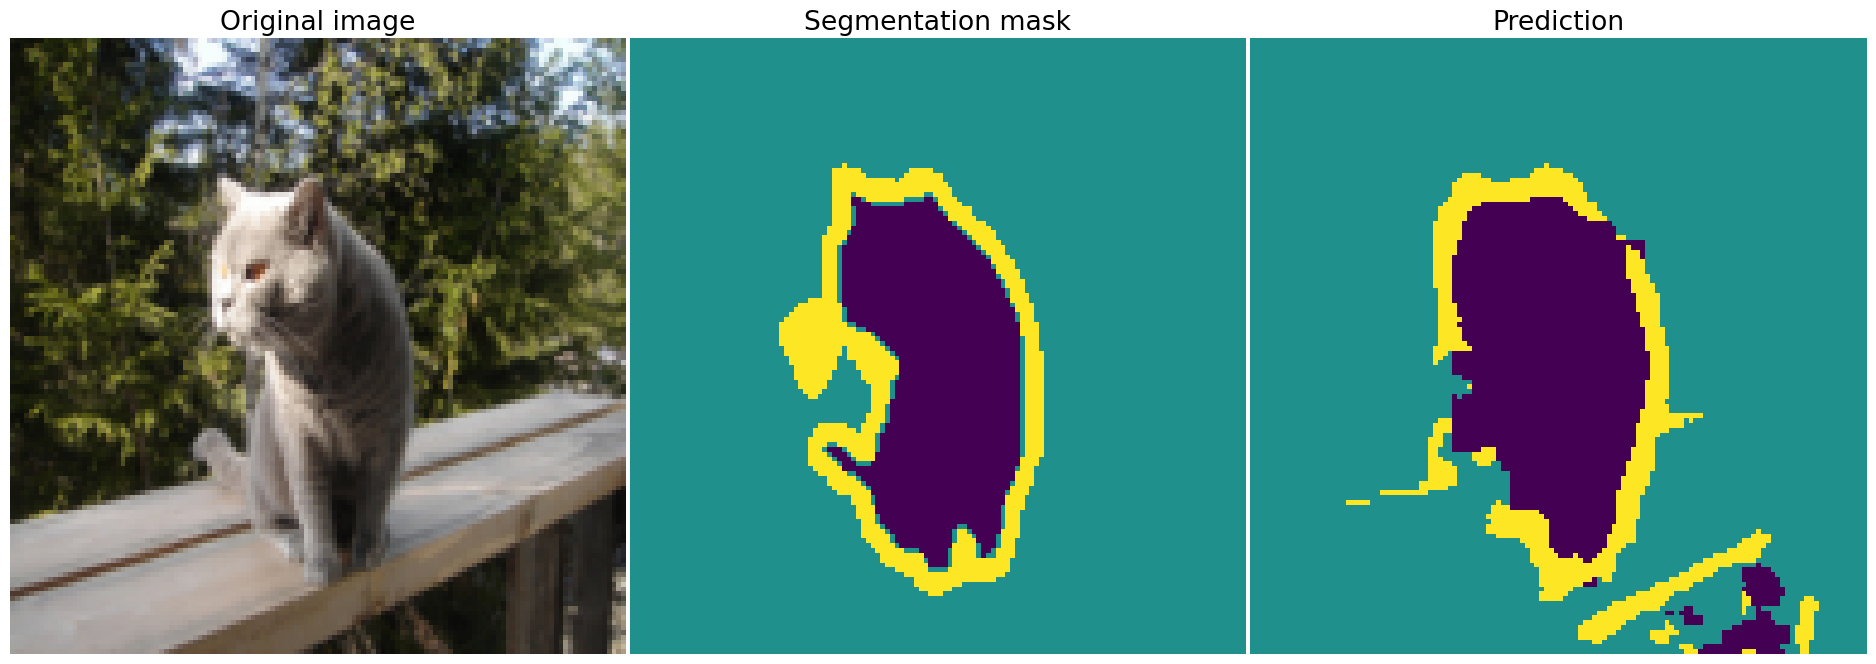

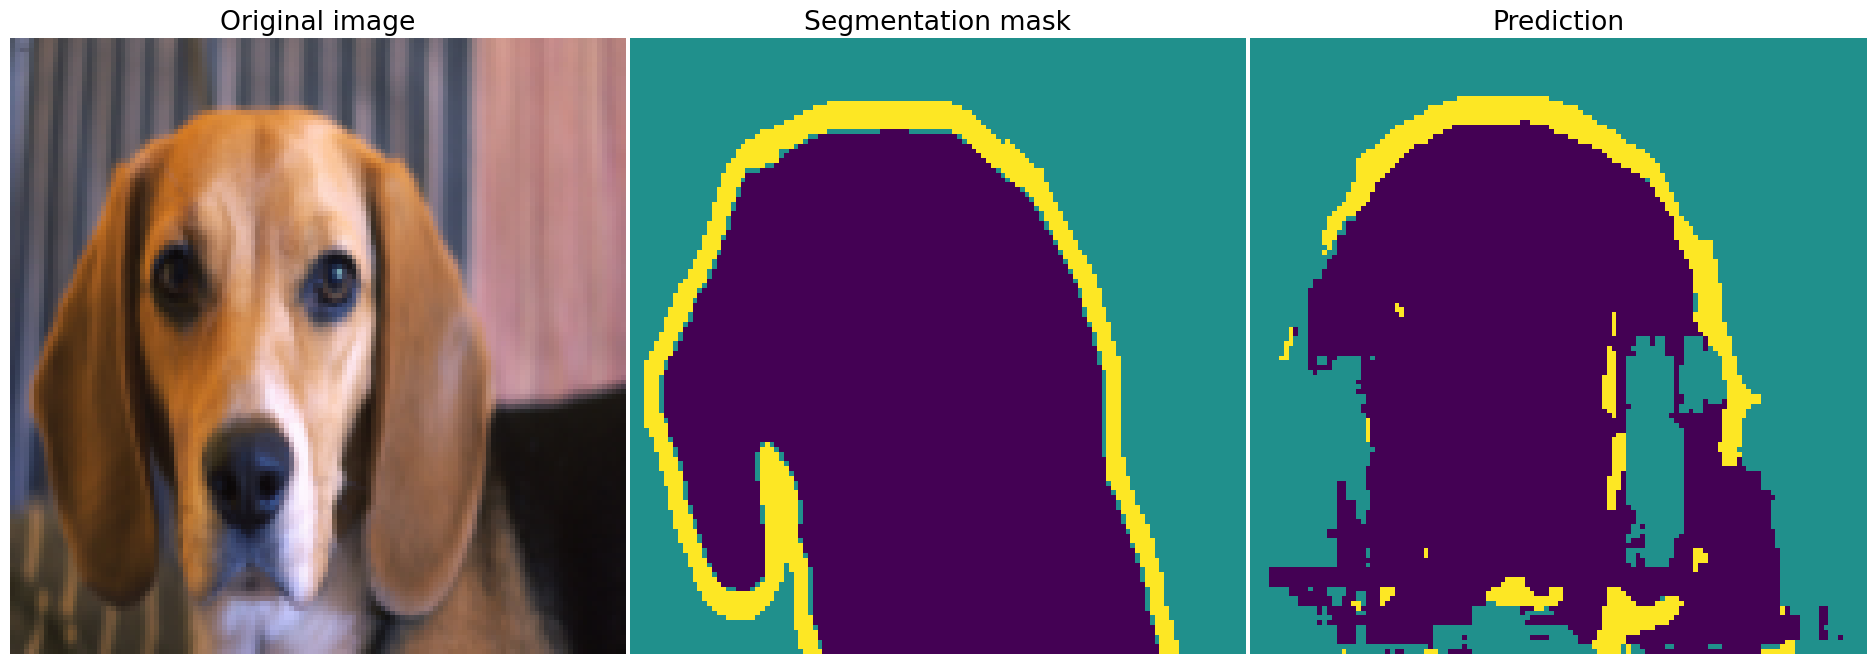

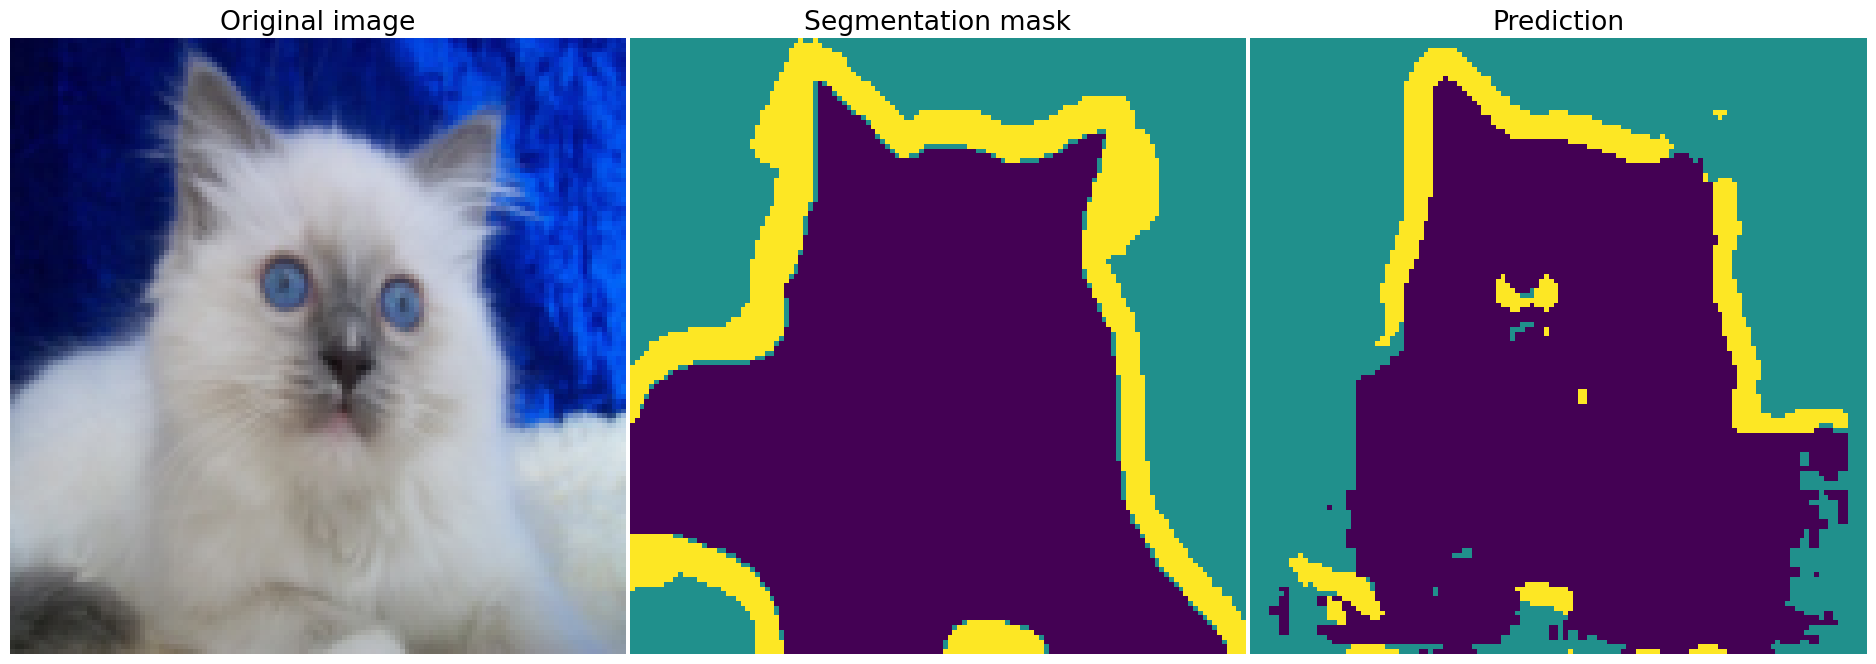

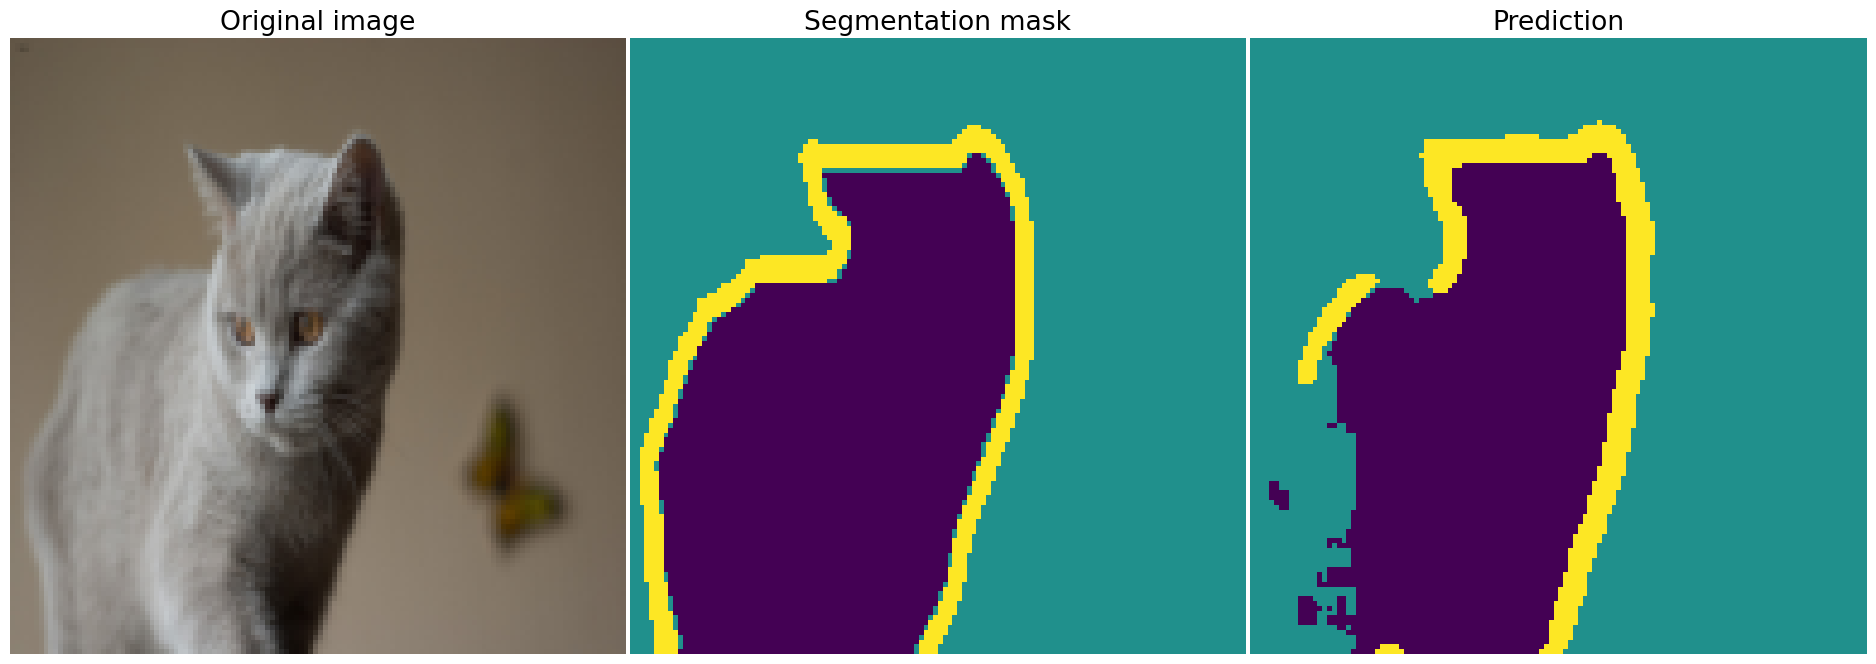

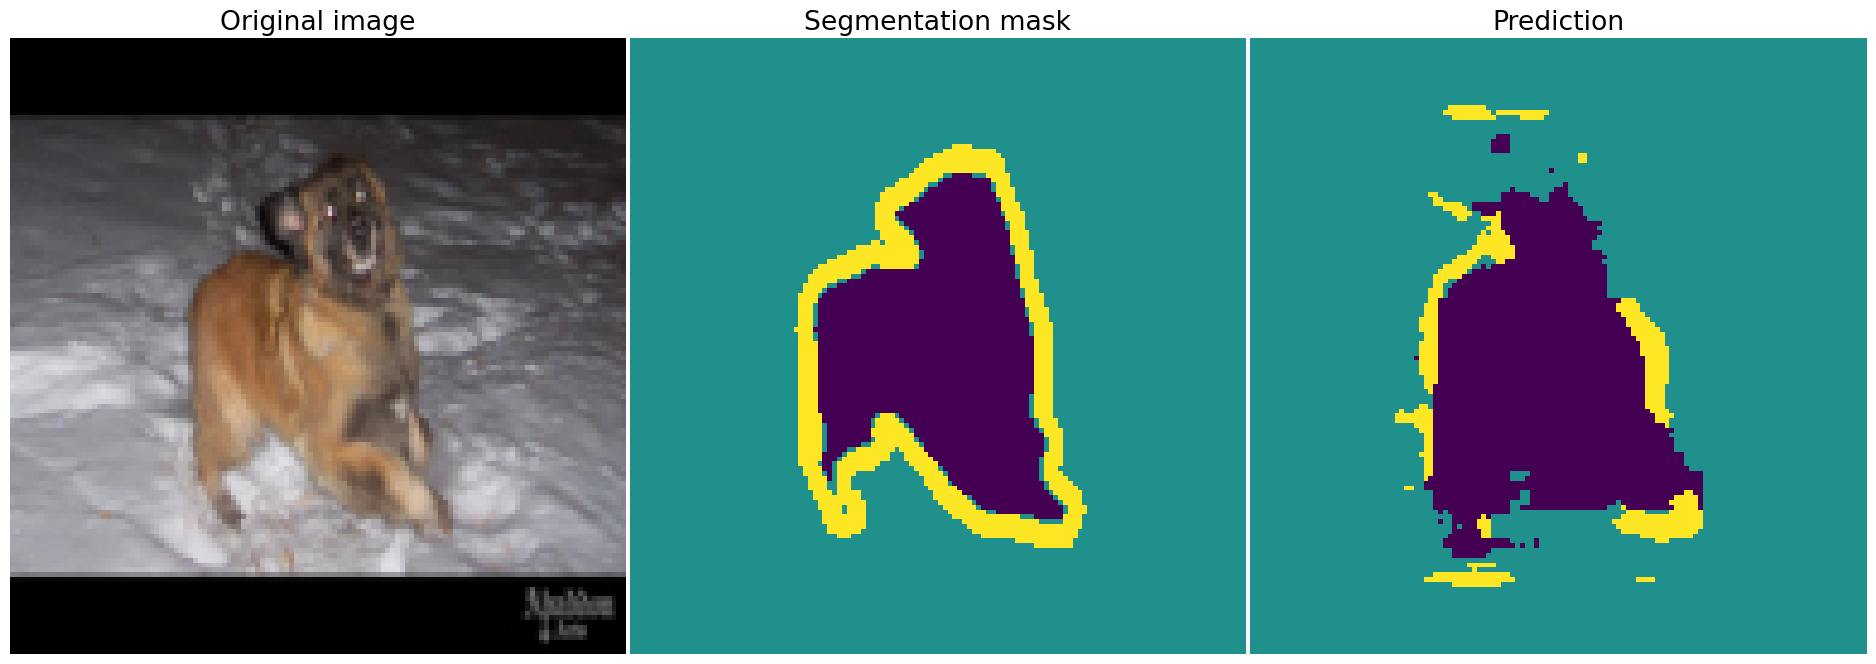

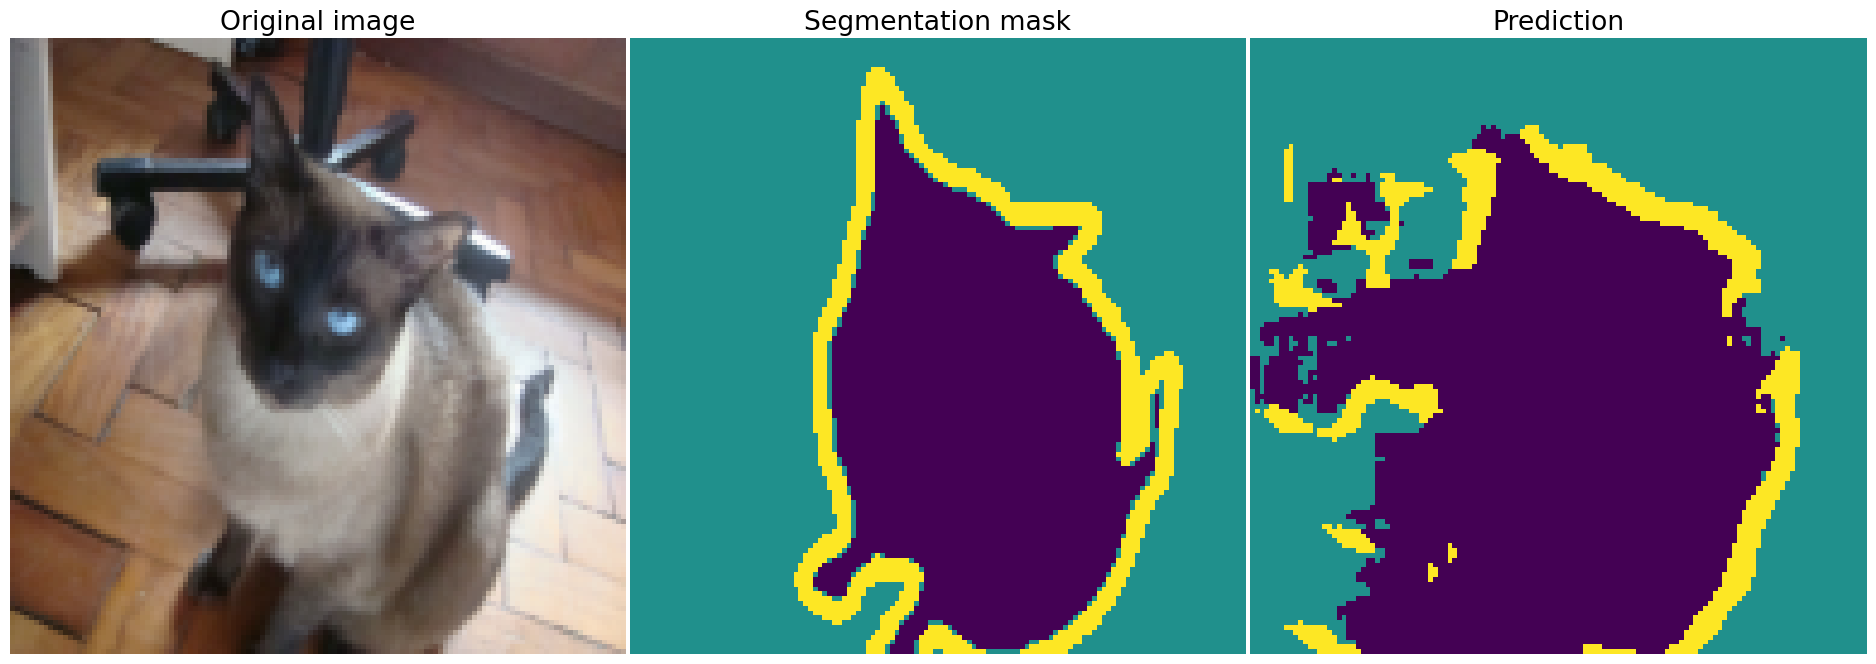

In [59]:
whole_train_valid_cycle(model, 40, 'UNET segmentation')

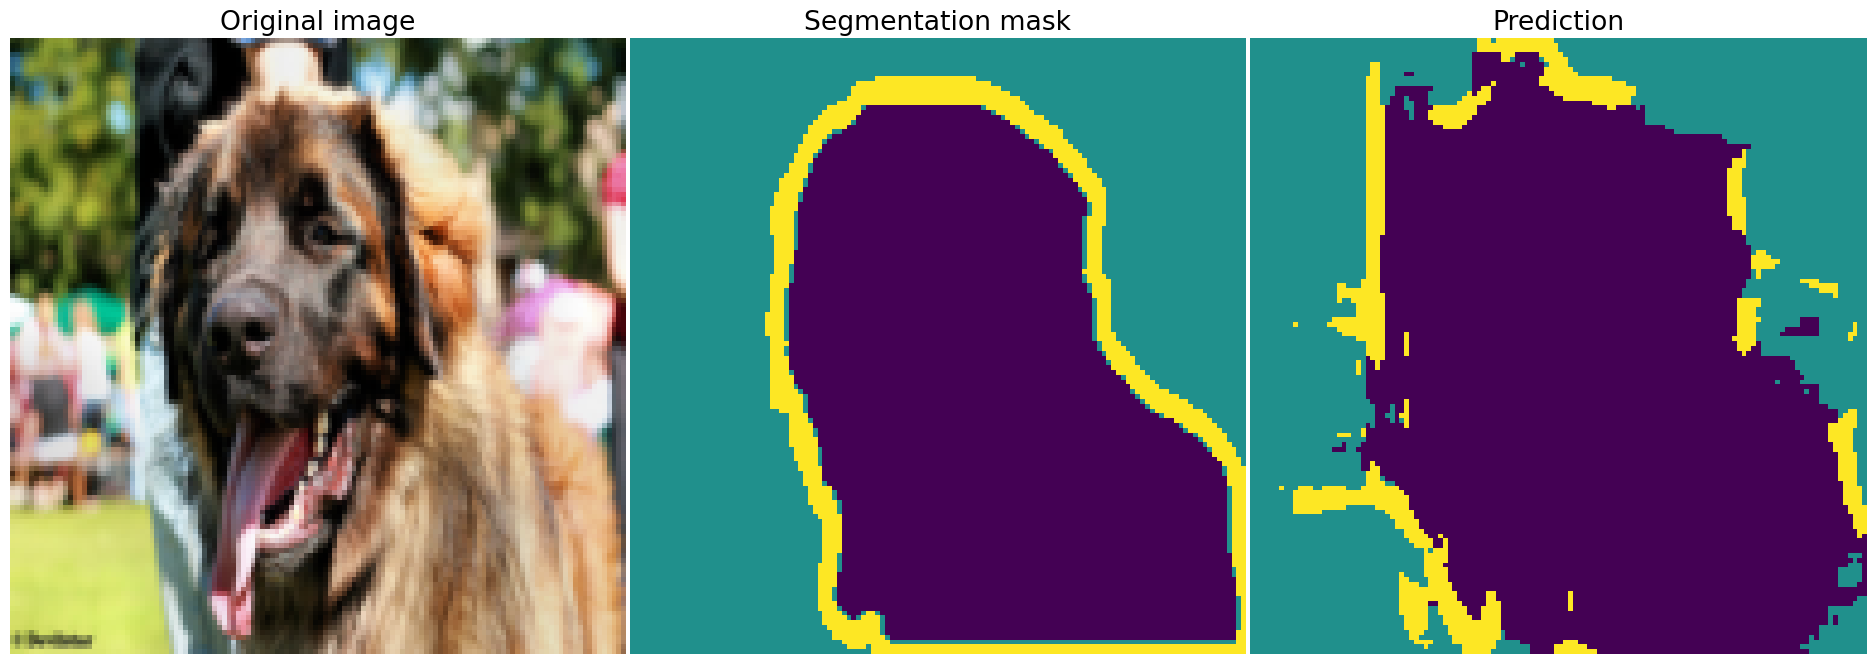

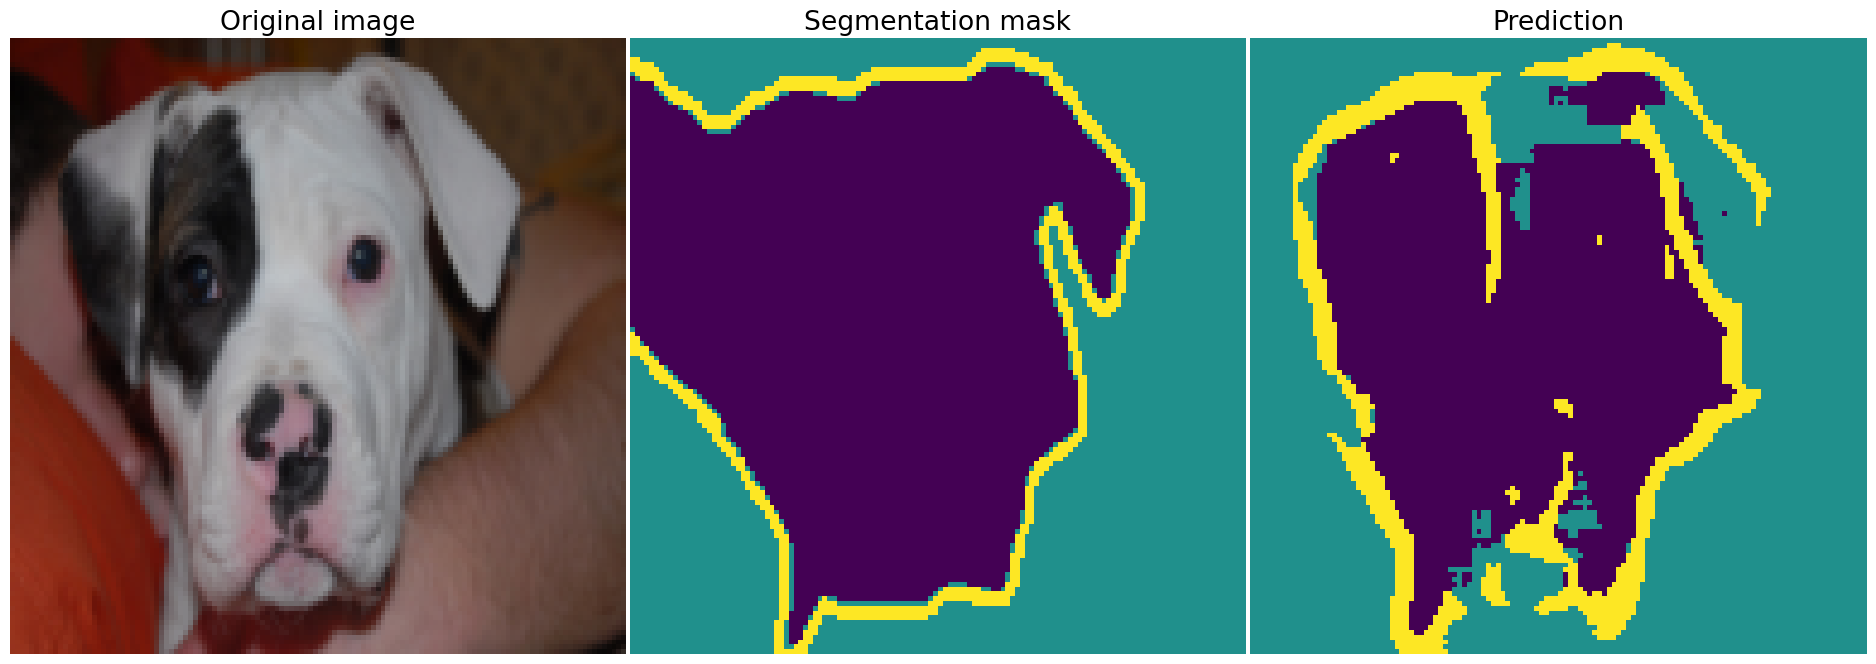

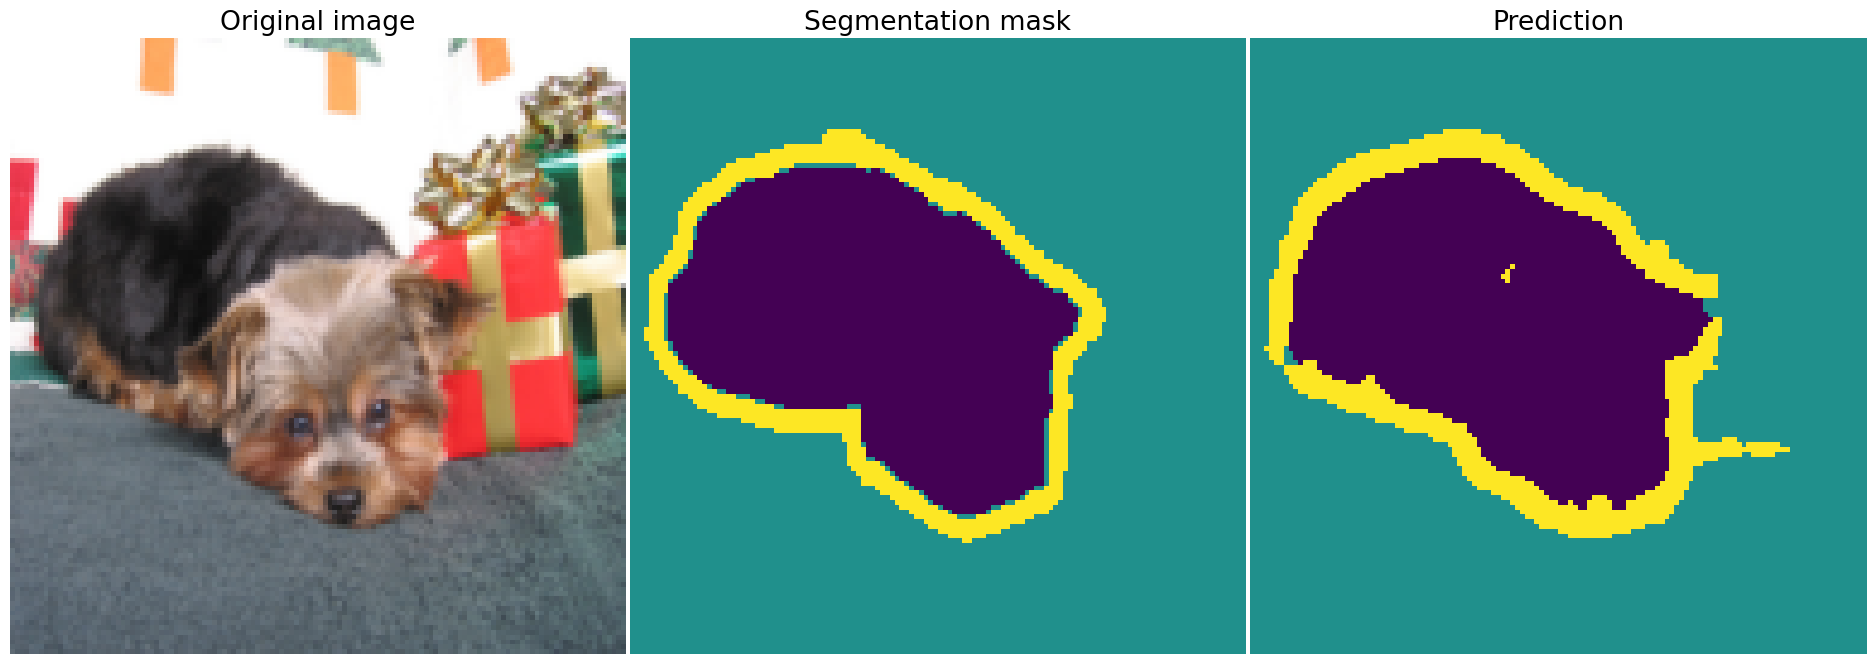

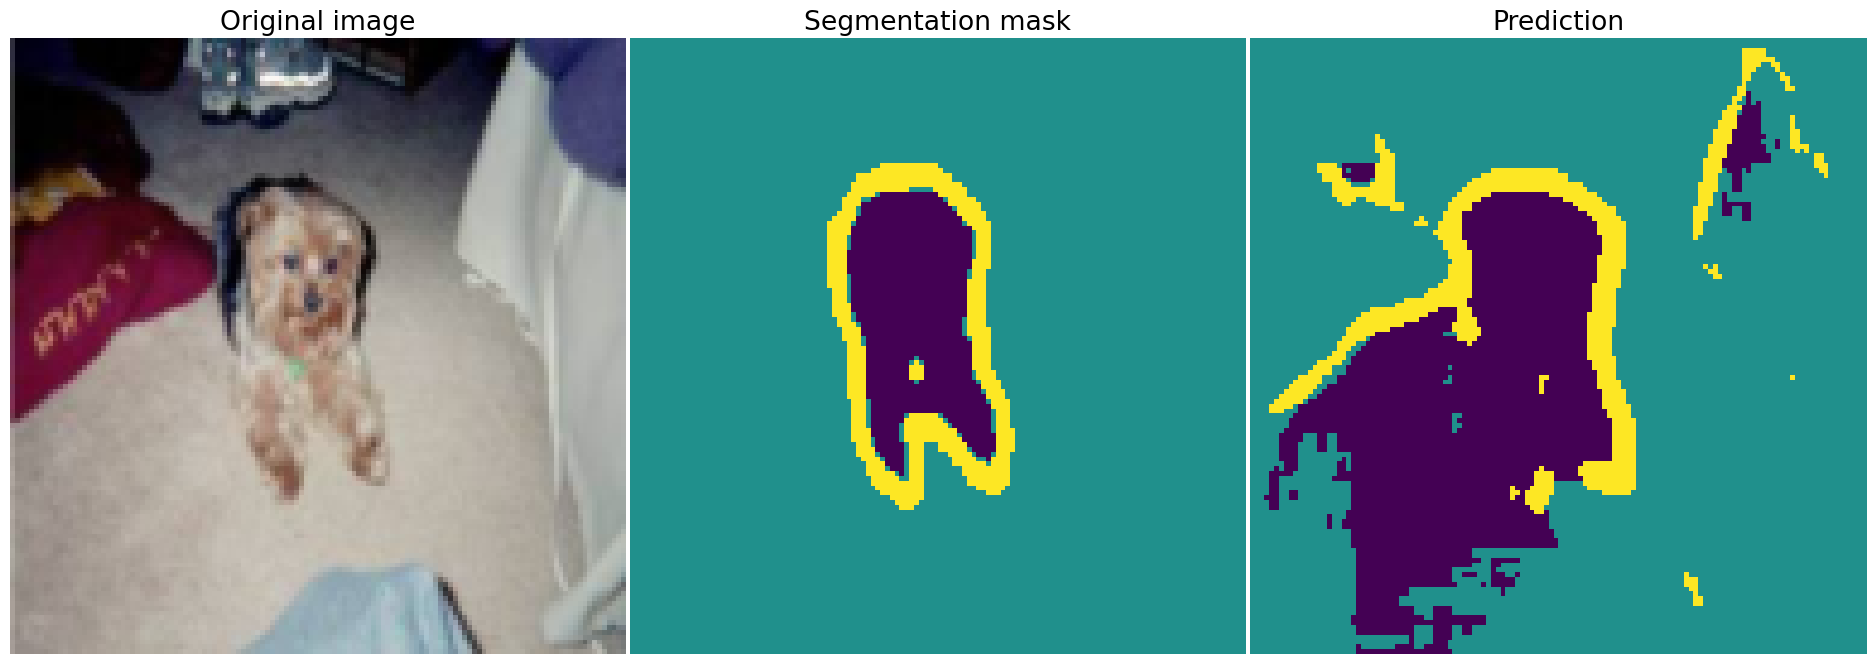

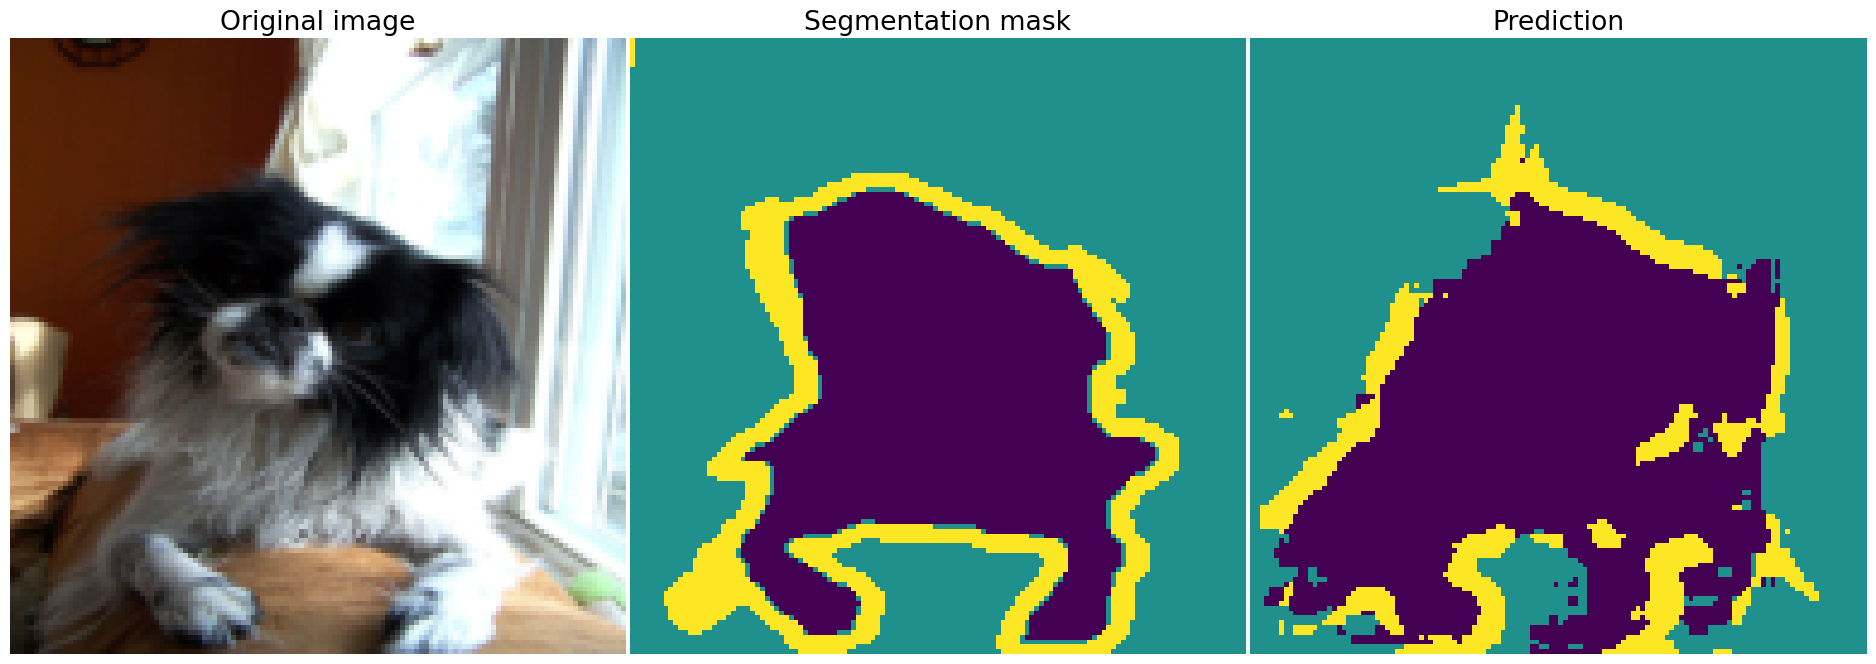

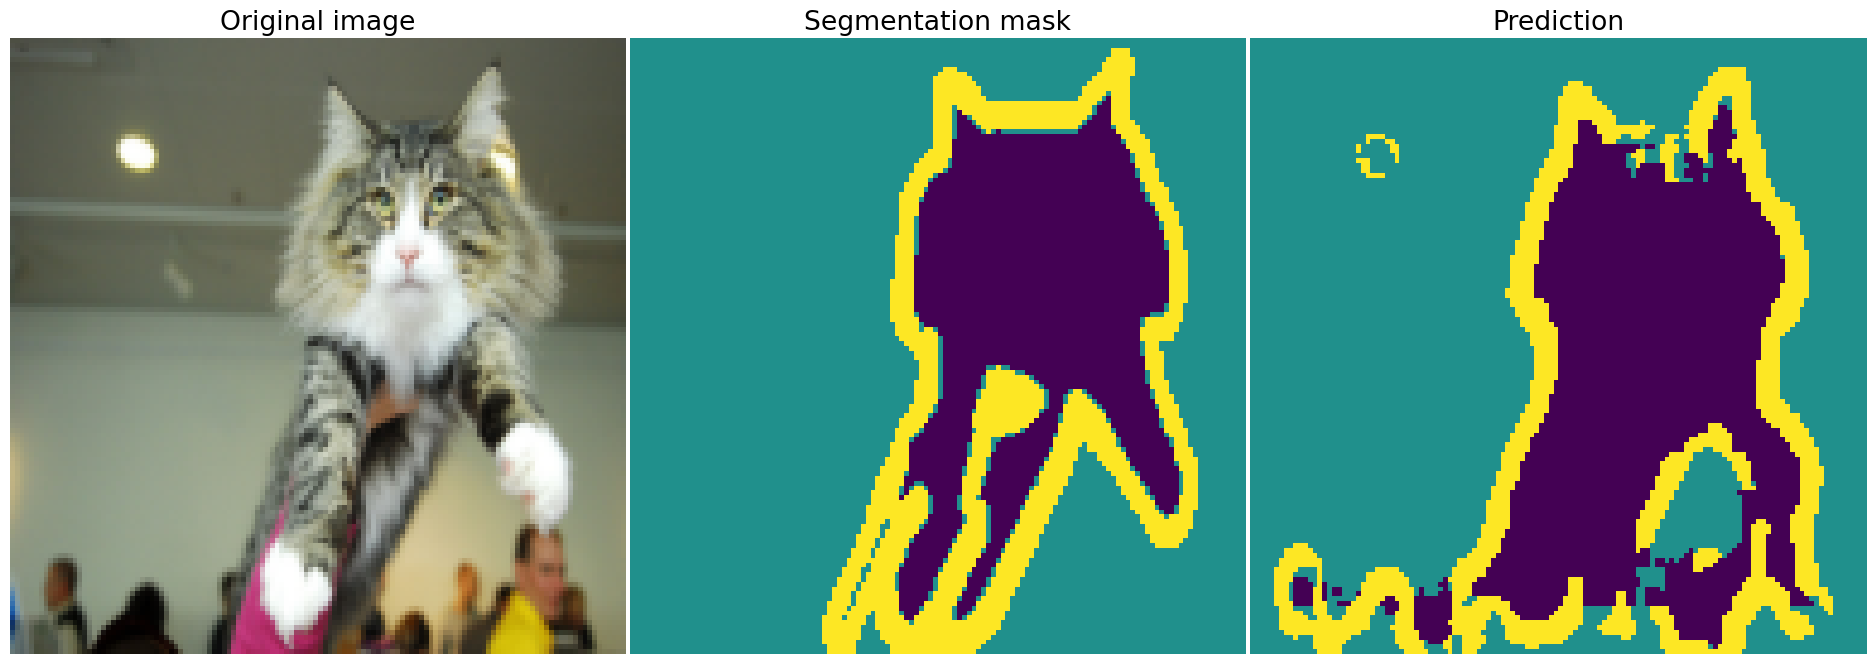

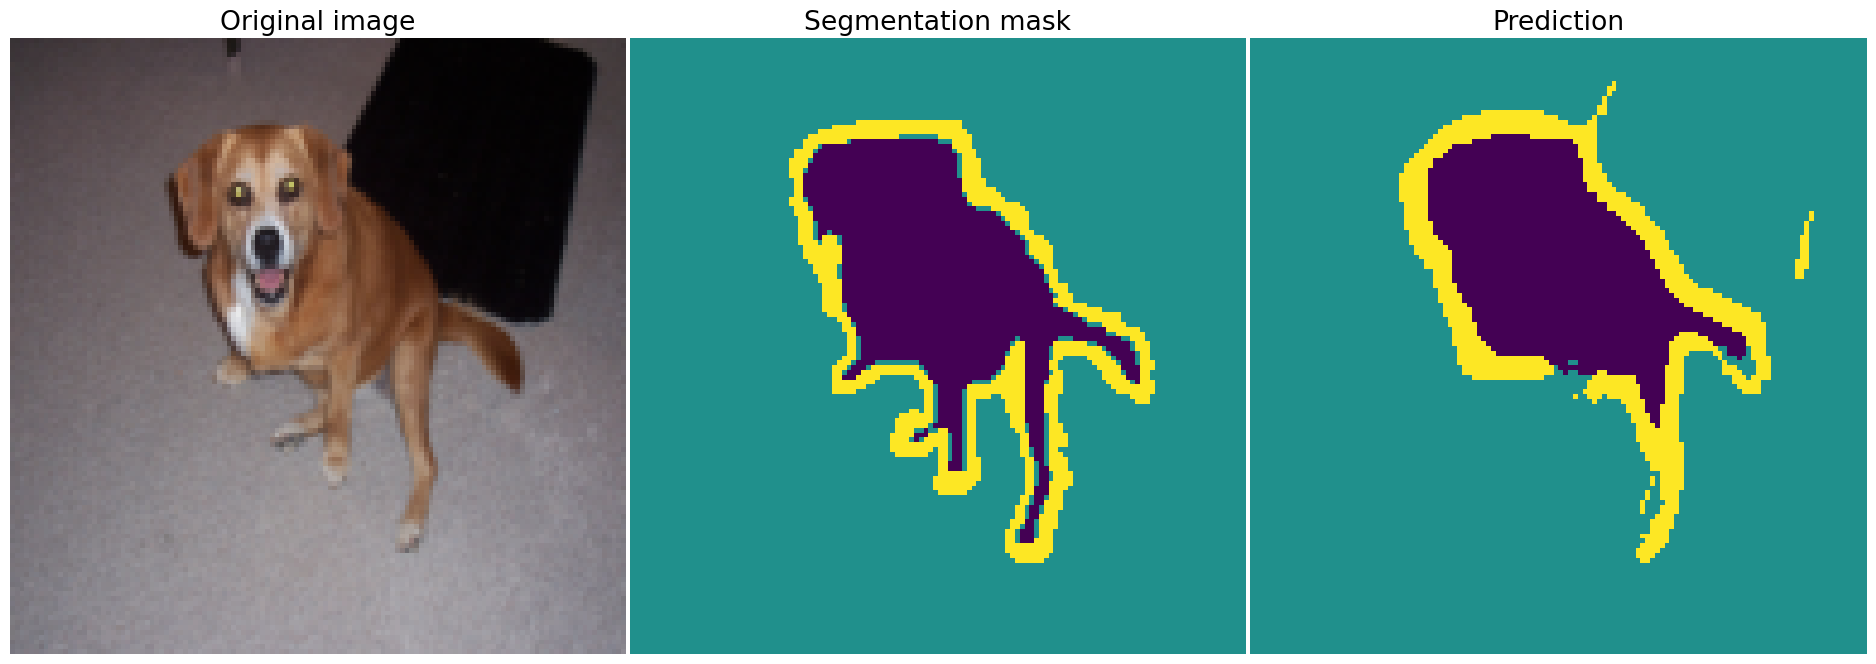

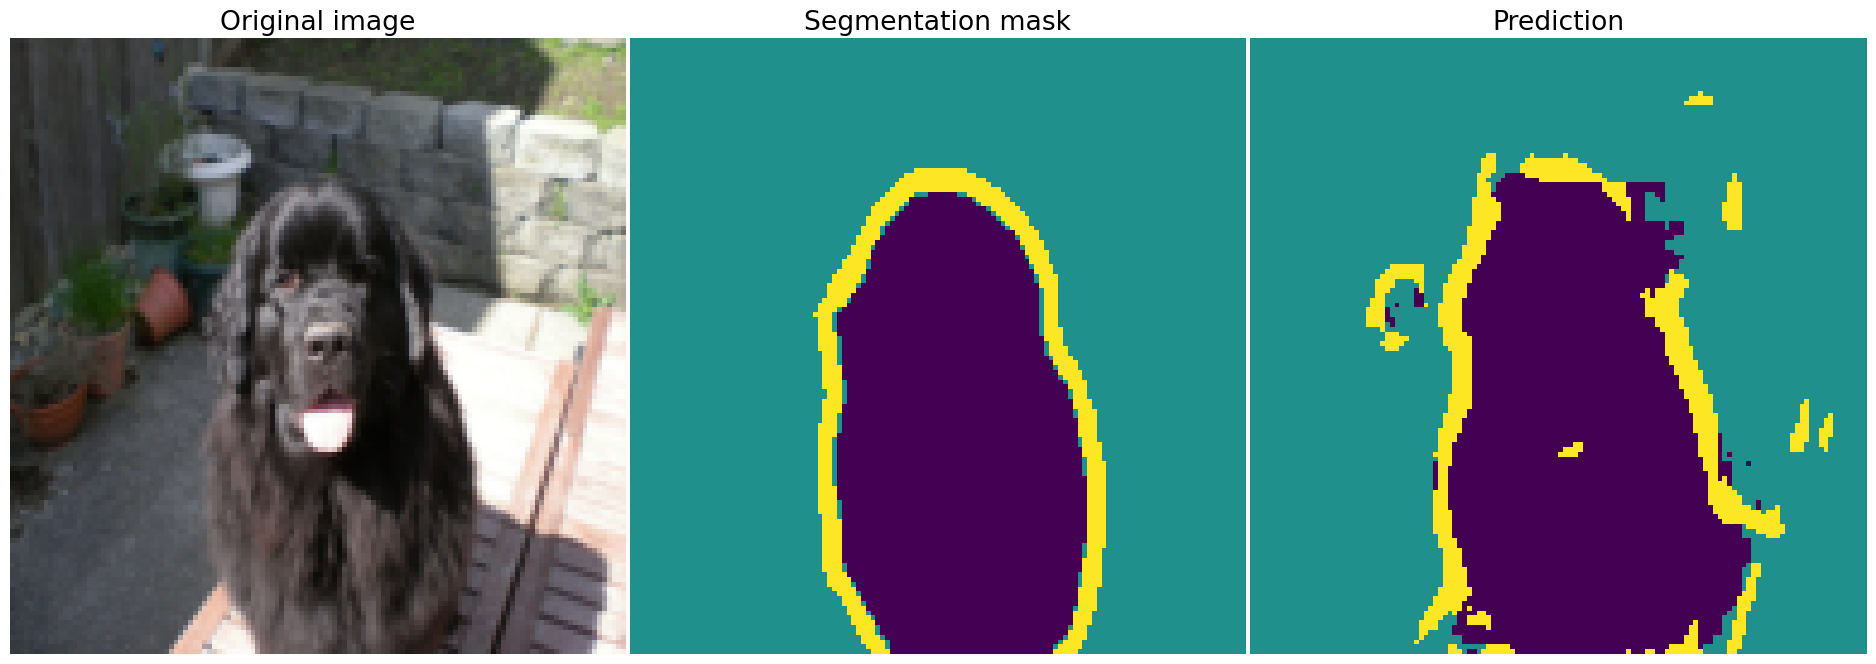

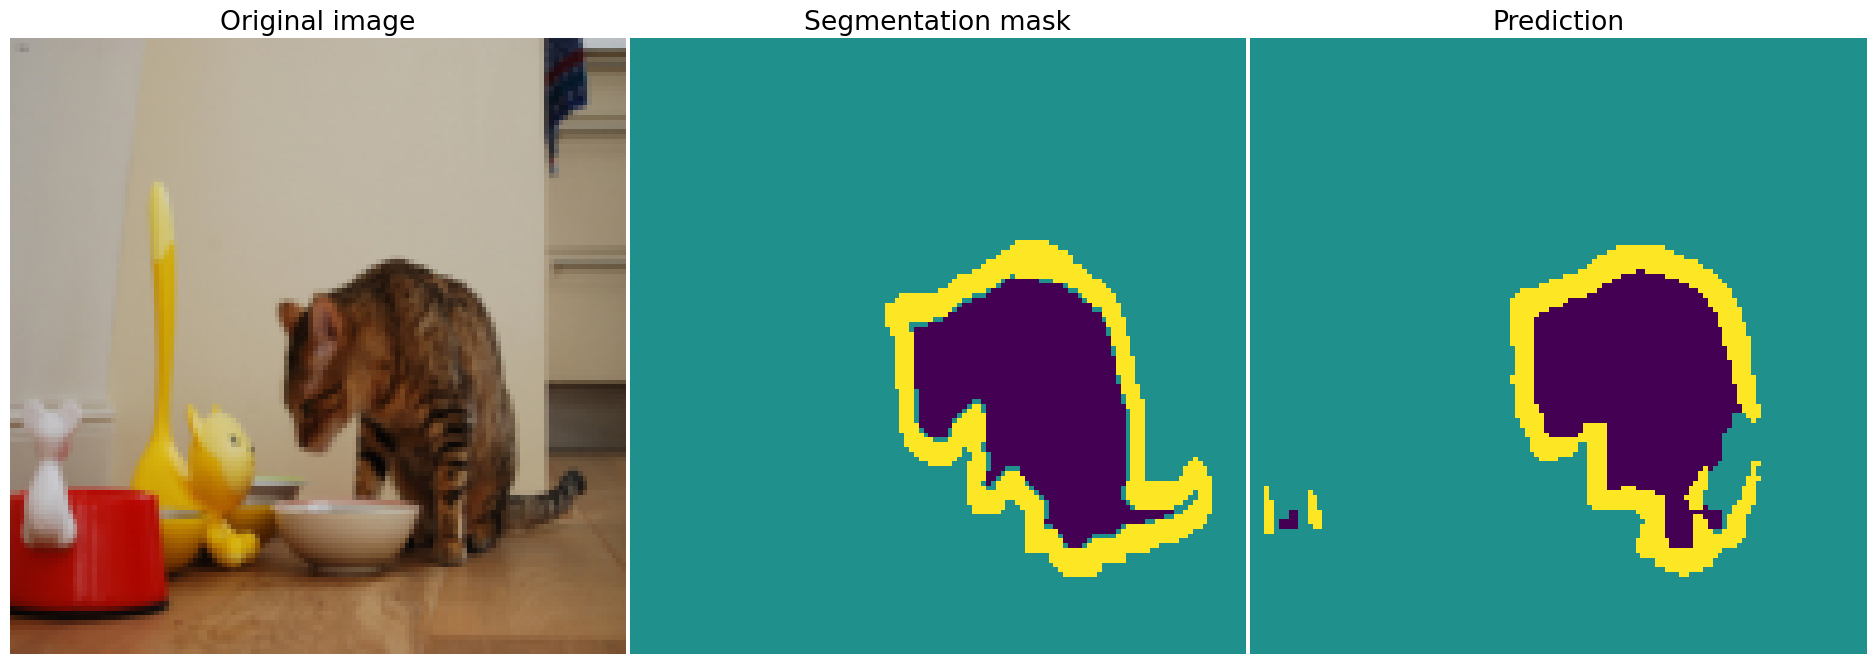

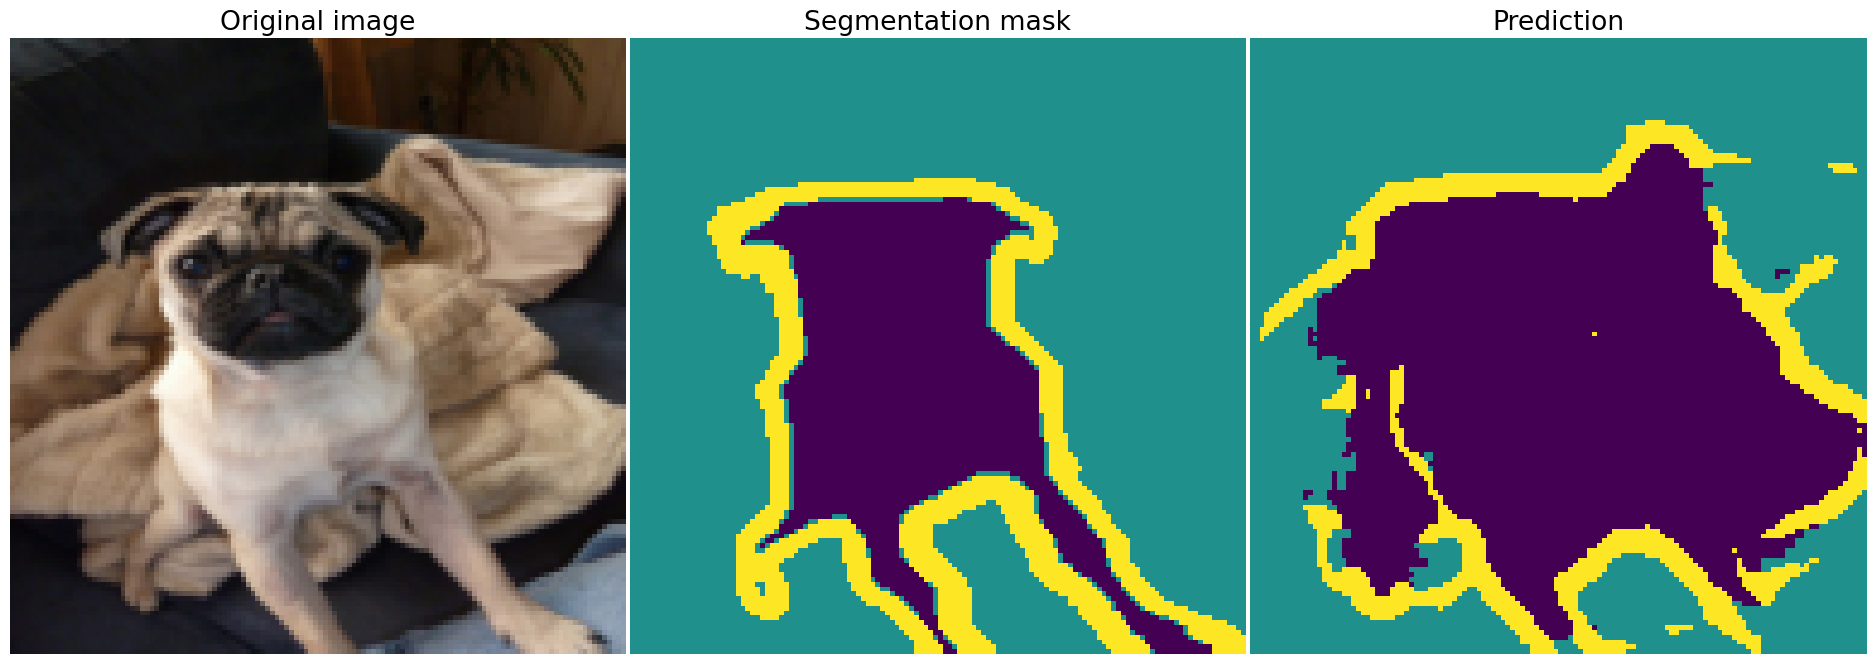

In [60]:
visualize(model, next(iter(train_loader)))

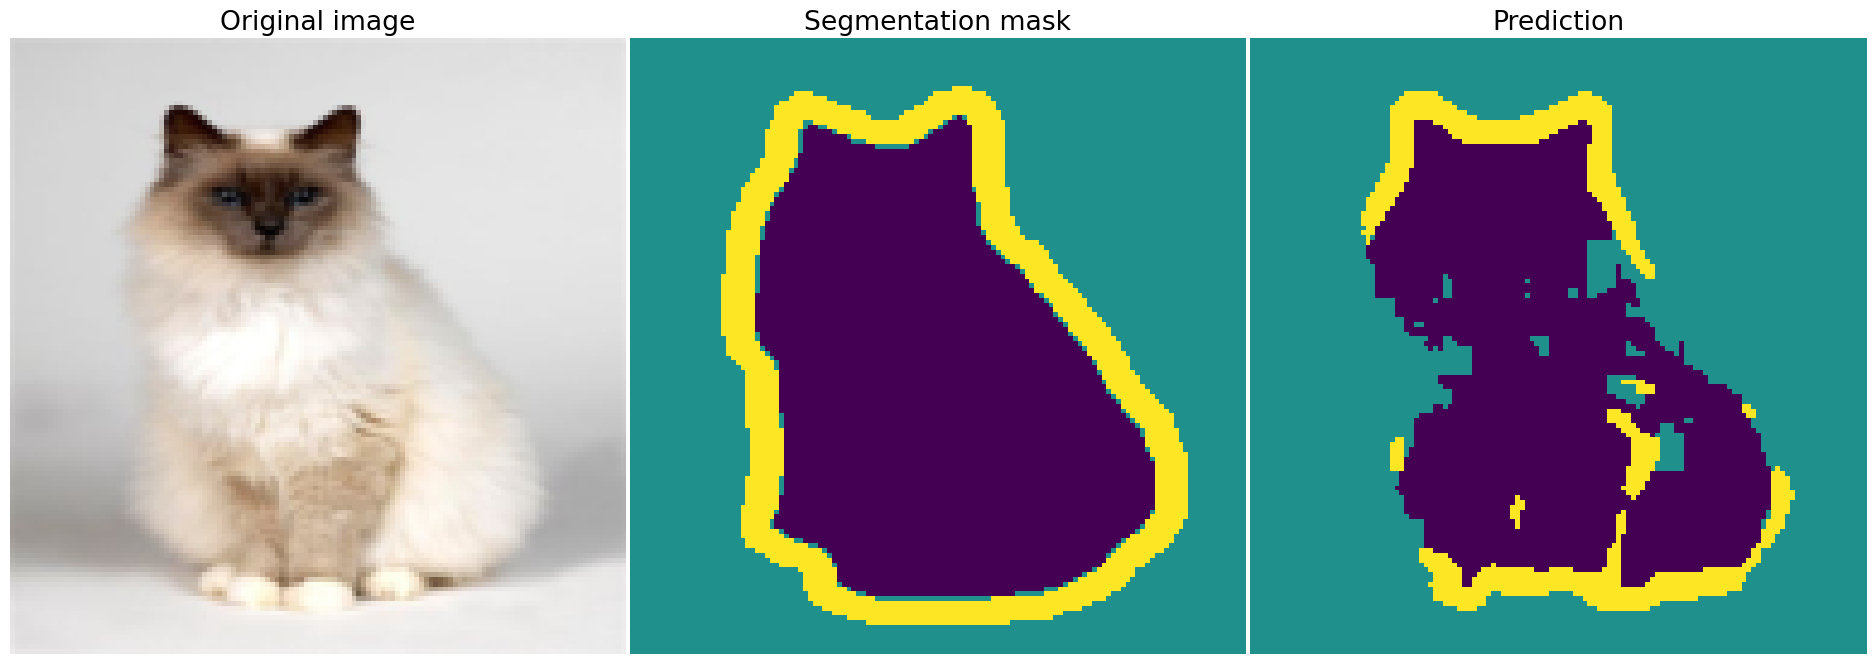

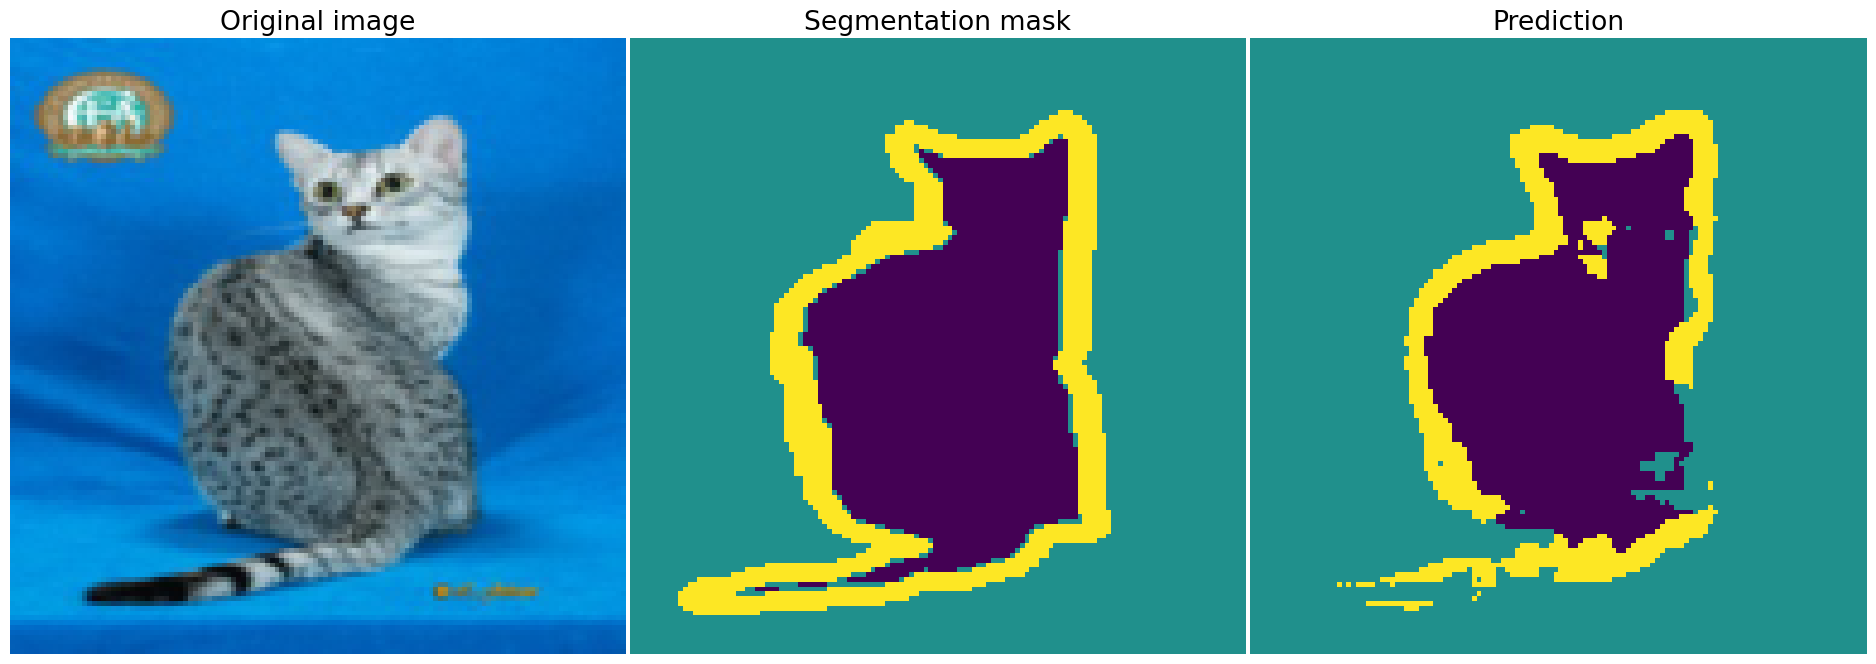

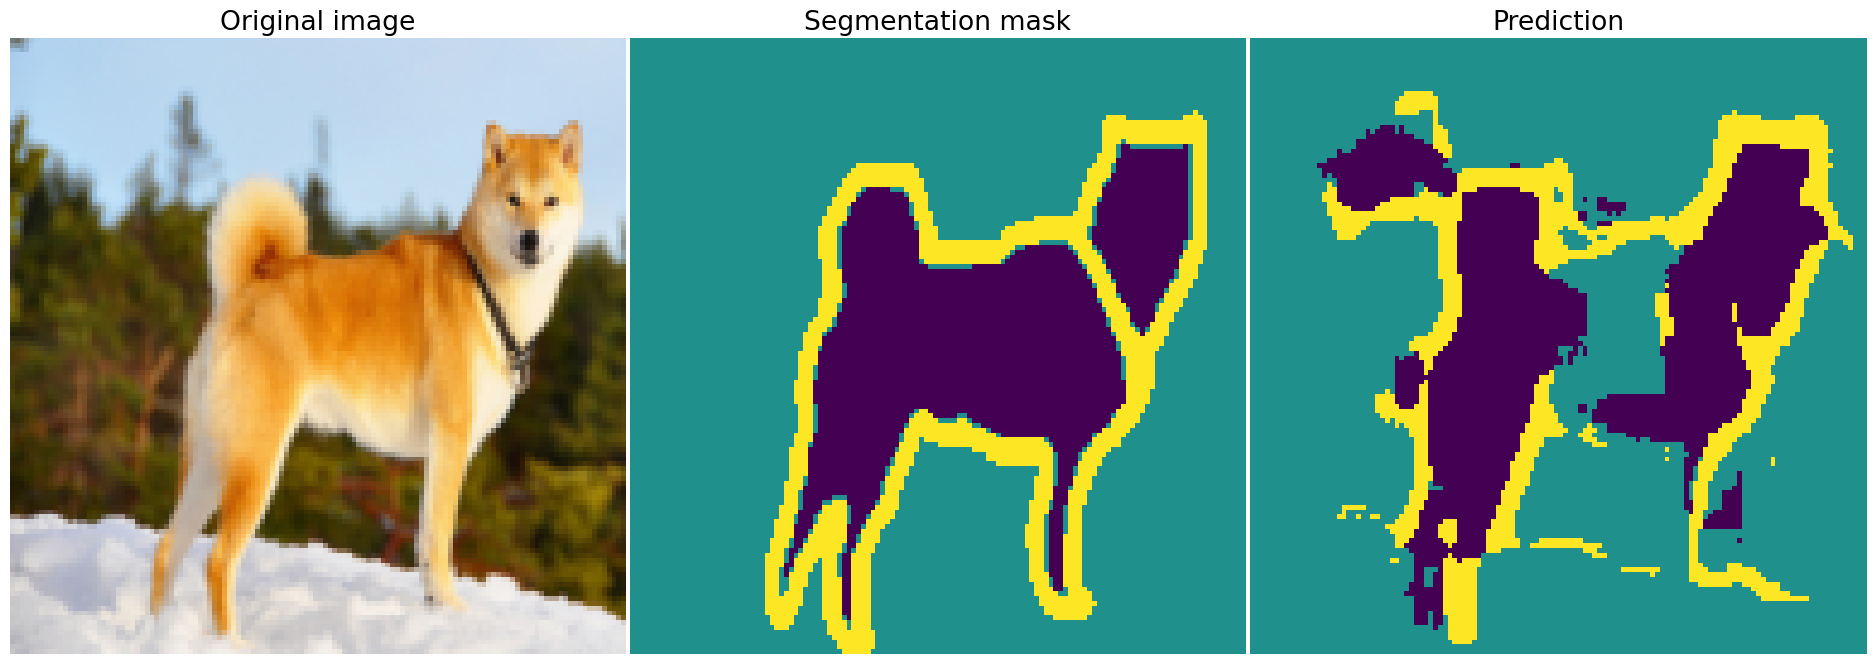

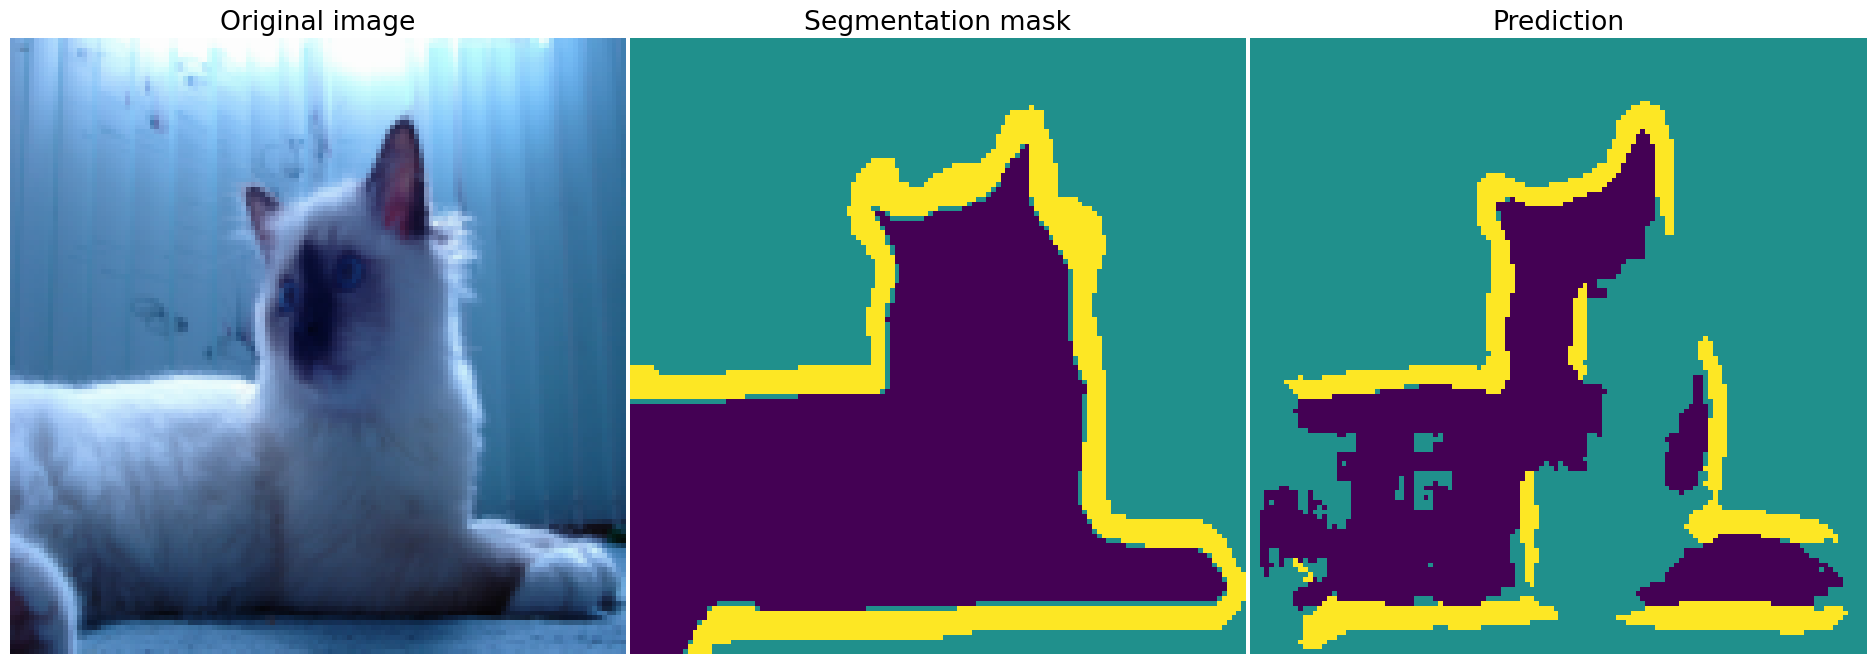

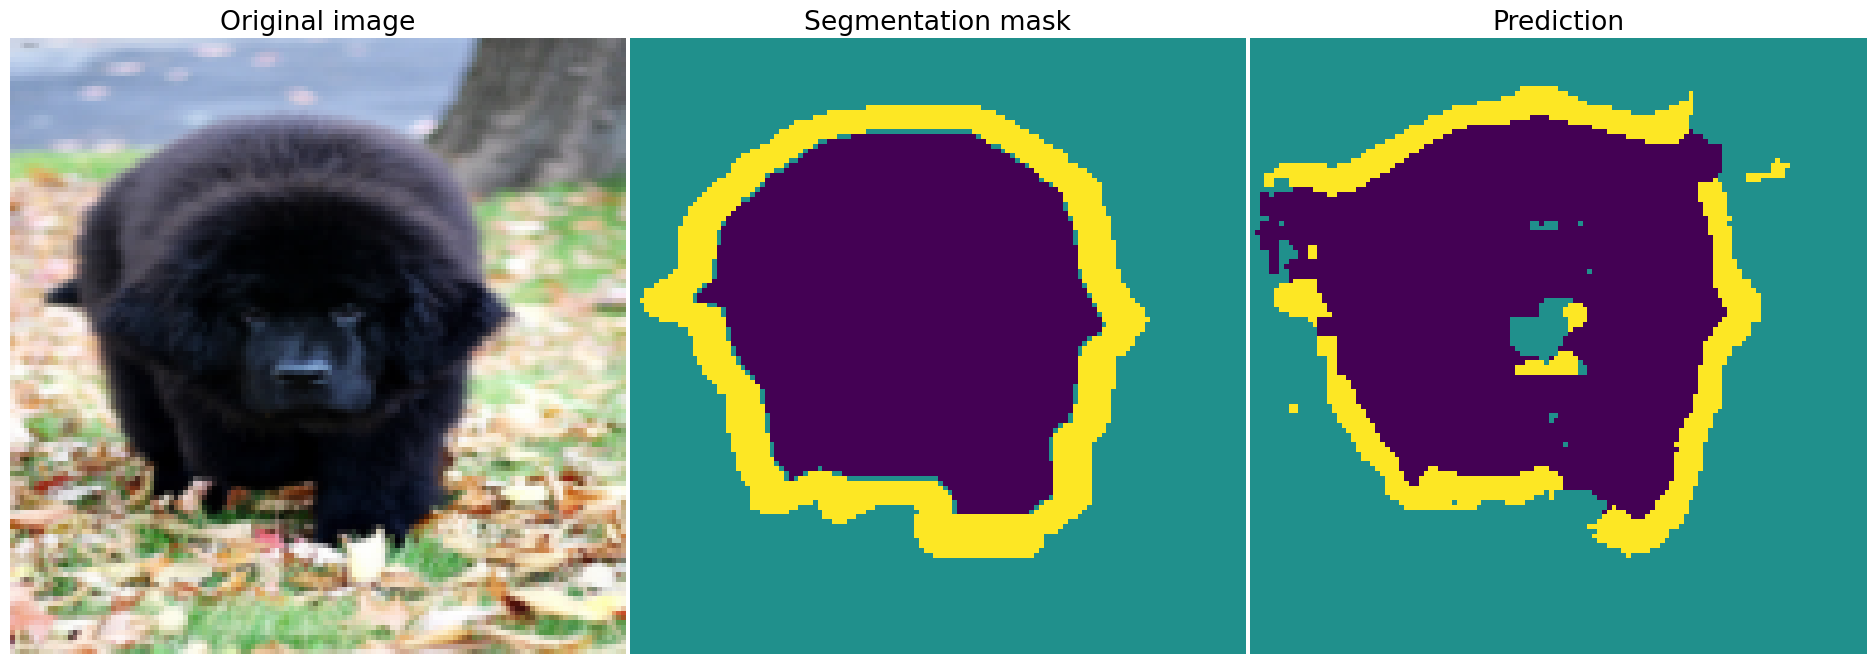

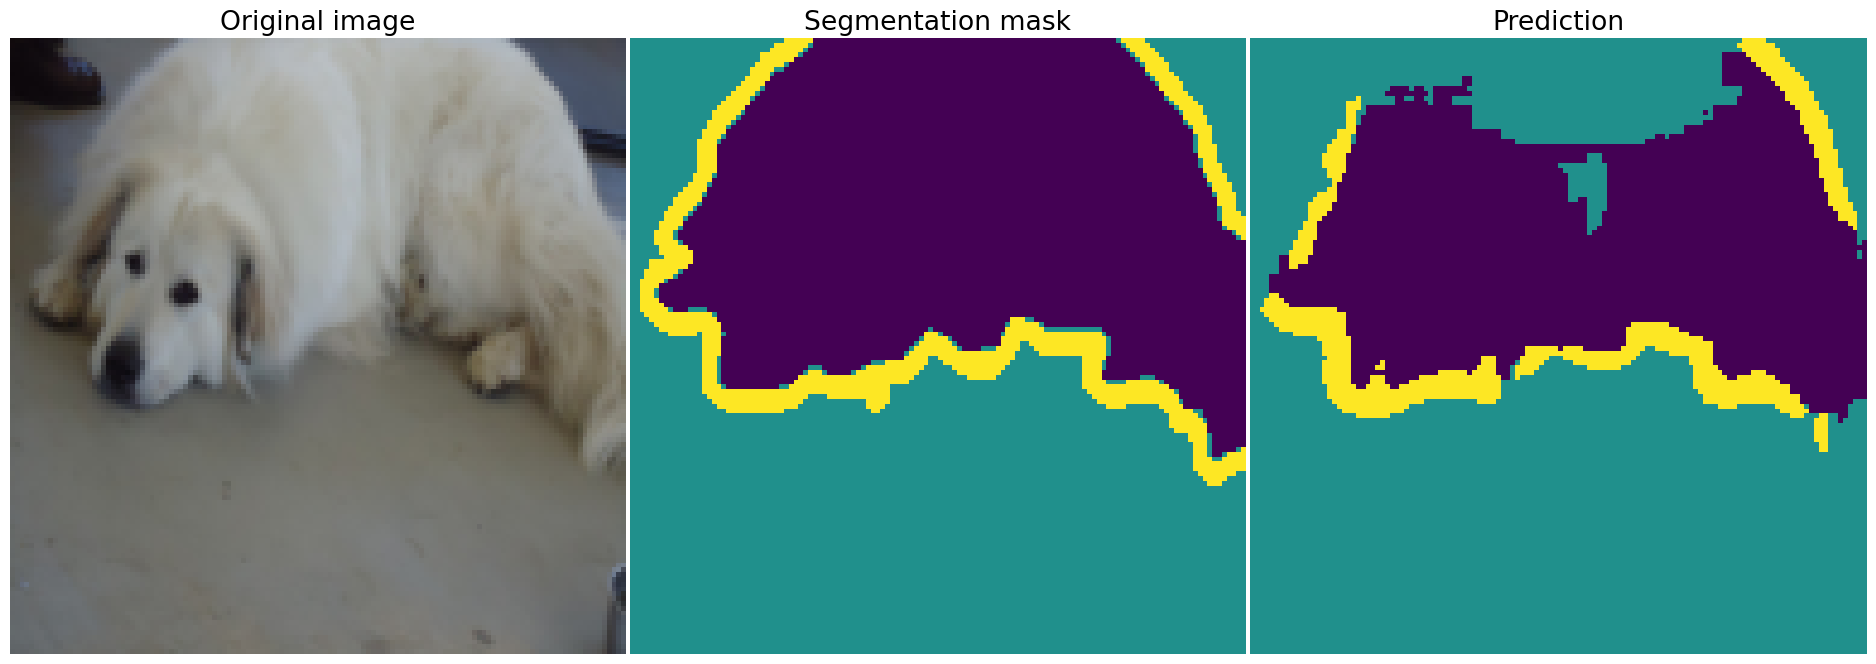

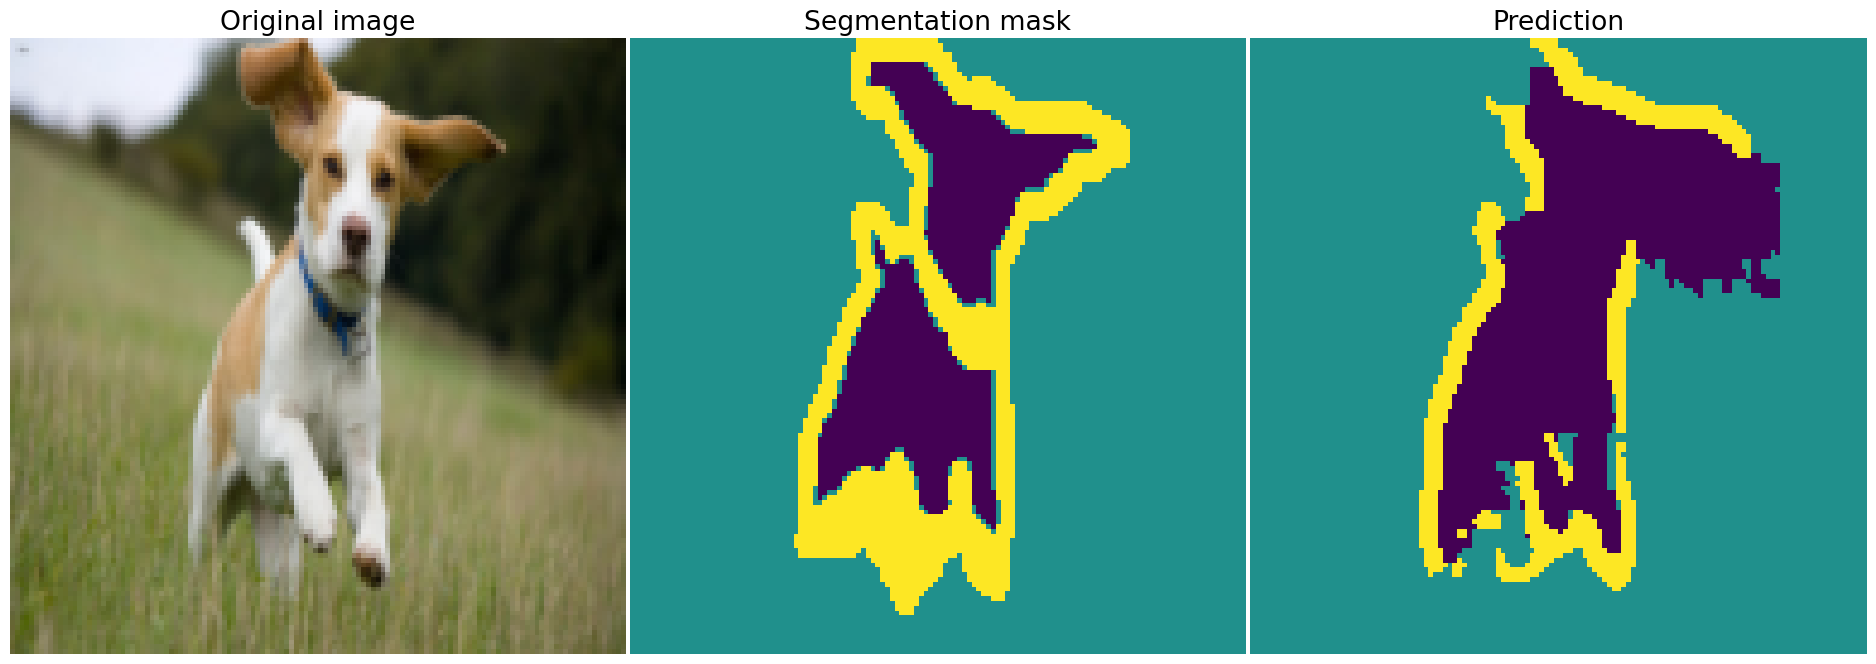

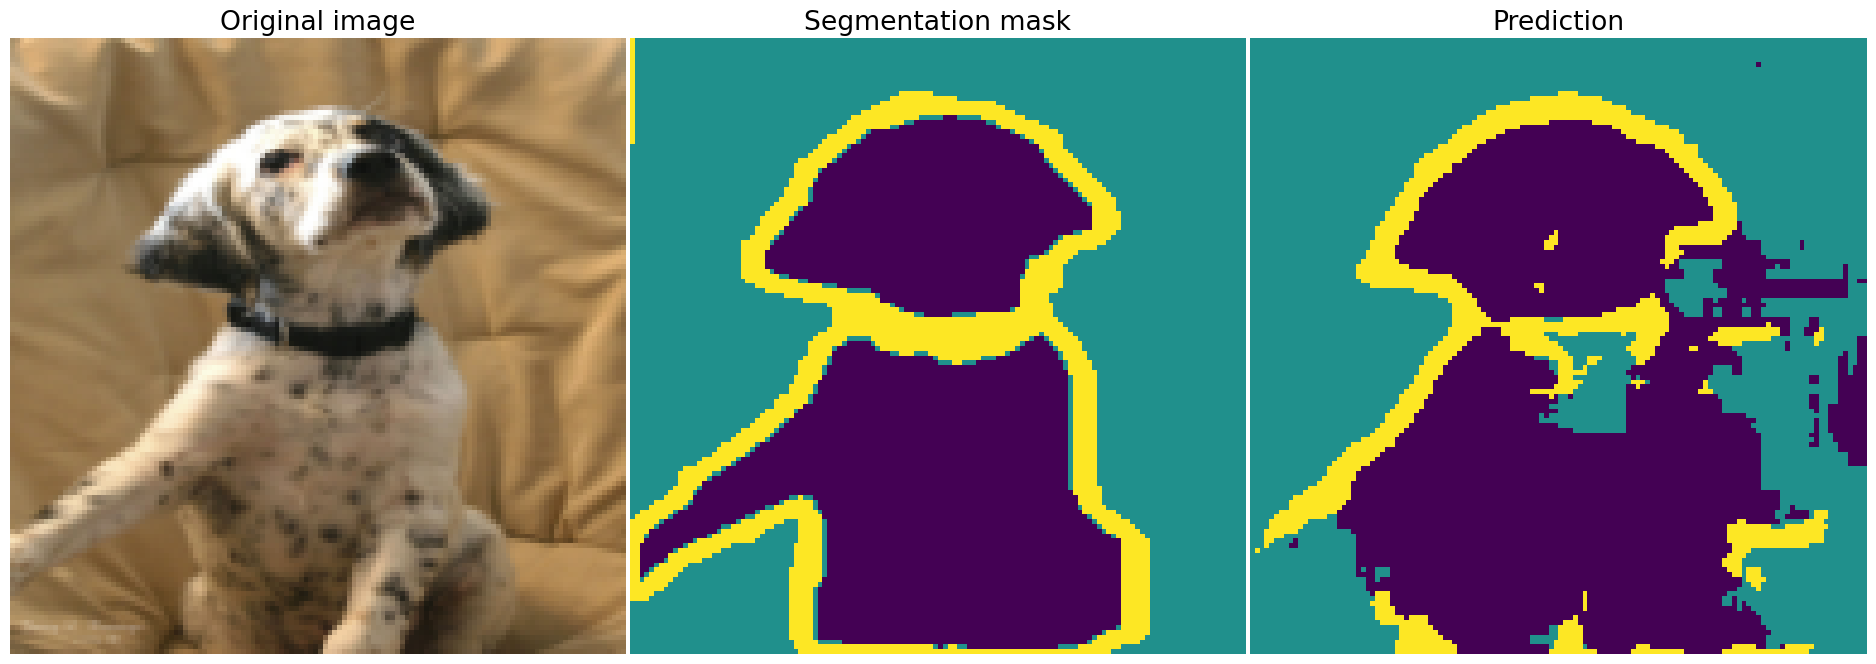

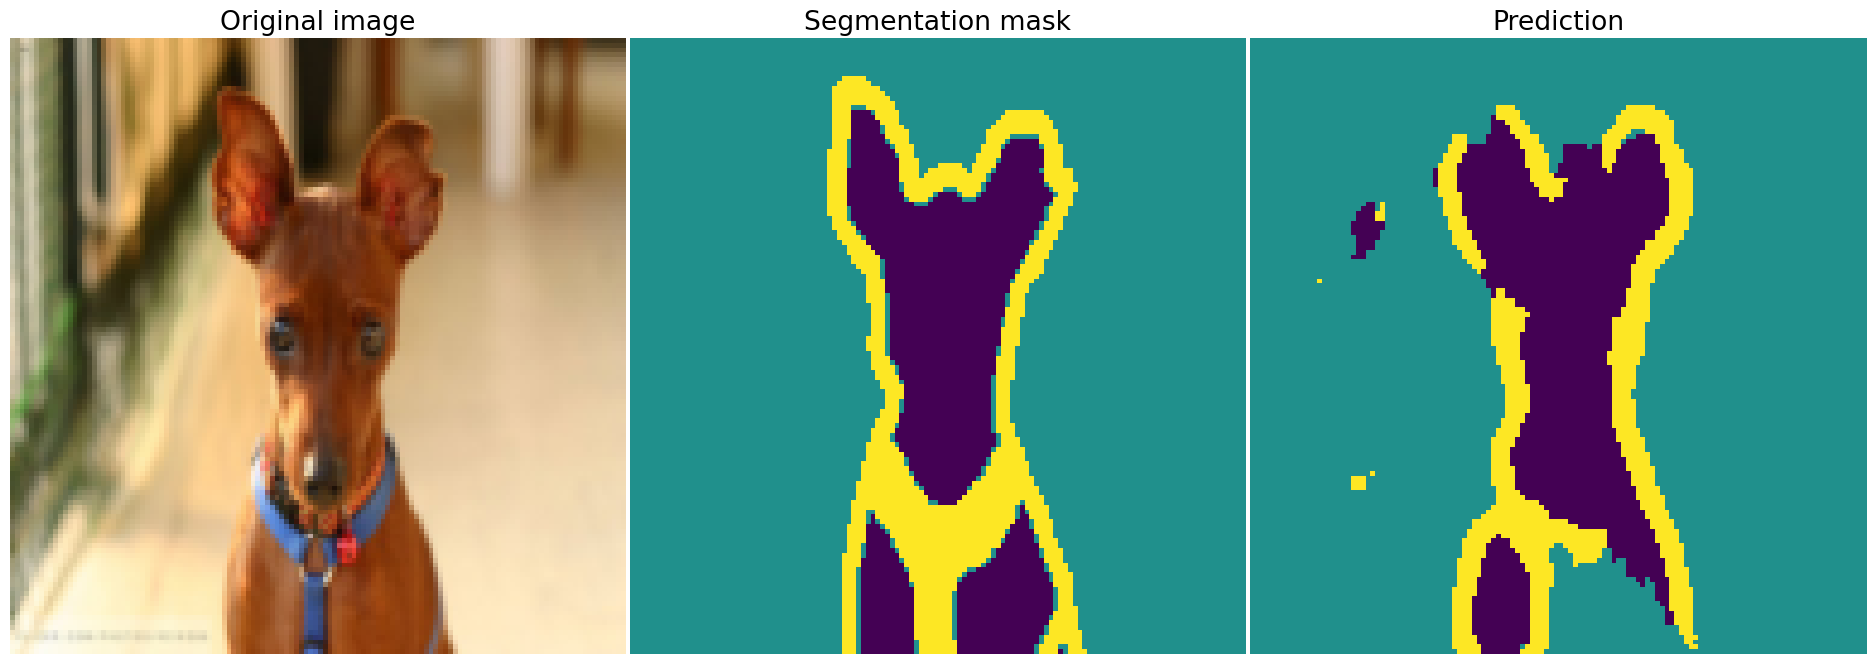

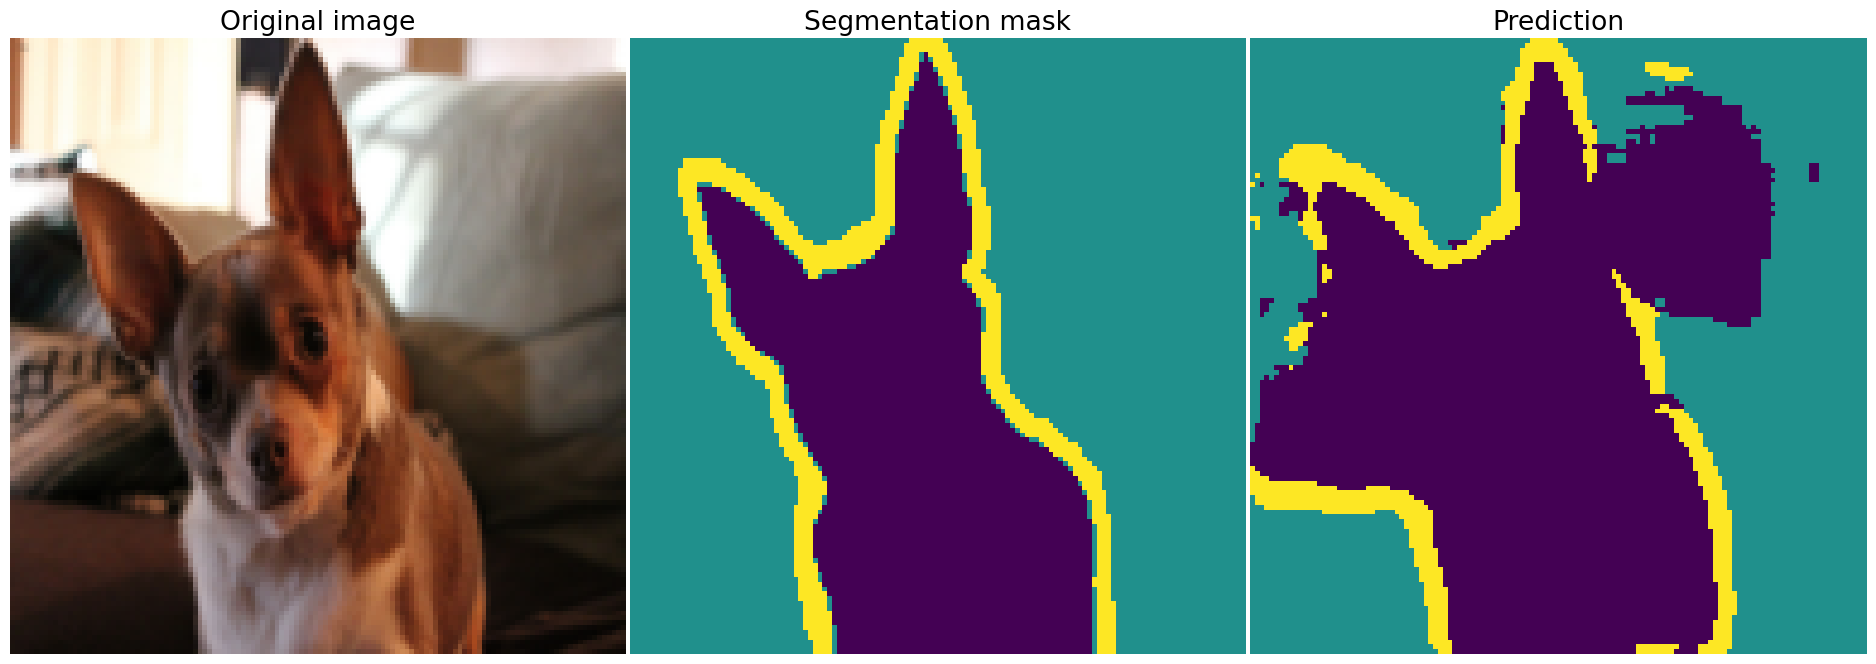

In [61]:
visualize(model, next(iter(valid_loader)))